<a href="https://colab.research.google.com/github/amolchopra/FlappyBird-SpriteBuilder/blob/master/Amol_Chopra_Full_Code_SuperKart_Model_Deployment_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SuperKart Sales Forecasting End-to-End ML Project

**Author:** Amol Chopra  
**Date:** May 2026  
**Project:** Predicting product-store sales revenue and deploying the model as a web service.

# Table of Contents

1. [Problem Statement & Objective](#1-problem-statement--objective)
2. [Library Installation & Imports](#2-library-installation--imports)
3. [Loading the Dataset](#3-loading-the-dataset)
4. [Data Overview](#4-data-overview)
   - 4.1 First and Last Rows
   - 4.2 Shape of the Dataset
   - 4.3 Data Types
   - 4.4 Statistical Summary
   - 4.5 Duplicate Check
   - 4.6 Missing Value Check
5. [Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis-eda)
   - 5.1 Univariate Analysis – Numerical Features
   - 5.2 Univariate Analysis – Categorical Features
   - 5.3 Bivariate Analysis – Correlation Heatmap
   - 5.4 Bivariate Analysis – Target vs. Numerical Features
   - 5.5 Bivariate Analysis – Target vs. Categorical Features
   - 5.6 Store-Level Deep Dive (OUT001 – OUT004)
   - 5.7 Multivariate Patterns
   - 5.8 EDA Insights Summary
6. [Data Preprocessing](#6-data-preprocessing)
   - 6.1 Standardising Sugar-Content Labels
   - 6.2 Feature Engineering – Product ID Prefix
   - 6.3 Feature Engineering – Store Age
   - 6.4 Feature Engineering – Perishable / Non-Perishable Category
   - 6.5 Outlier Detection and Treatment Decision
   - 6.6 Data Preparation (drop columns, train/test split)
   - 6.7 Preprocessing Pipeline (categorical encoding)
7. [Model Building](#7-model-building)
   - 7.1 Choice of Evaluation Metric – Rationale
   - 7.2 Model Evaluation Helper Function
   - 7.3 Model 1 – Random Forest Regressor (baseline)
   - 7.4 Model 2 – XGBoost Regressor (baseline)
8. [Hyperparameter Tuning](#8-hyperparameter-tuning)
   - 8.1 Tuned Random Forest
   - 8.2 Tuned XGBoost
9. [Model Comparison, Final Selection & Serialization](#9-model-comparison-final-selection--serialization)
   - 9.1 Train Performance Comparison
   - 9.2 Test Performance Comparison
   - 9.3 Final Model Selection & Justification
   - 9.4 Saving (Serializing) the Model with joblib
   - 9.5 Loading the Saved Model & Sanity-Check Predictions
10. [Deployment – Backend (Flask + Docker on Hugging Face)](#10-deployment--backend)
    - 10.1 Flask API
    - 10.2 Dependencies File
    - 10.3 Dockerfile
    - 10.4 Creating the Hugging Face Docker Space
    - 10.5 Uploading the Backend Files
    - 10.6 Testing the Live API
11. [Deployment – Frontend (Streamlit on Hugging Face)](#11-deployment--frontend)
    - 11.1 Streamlit App
    - 11.2 Dependencies & Dockerfile
    - 11.3 Creating the Hugging Face Streamlit Space
    - 11.4 Uploading the Frontend Files
12. [Actionable Insights & Business Recommendations](#12-actionable-insights--business-recommendations)
13. [Final Conclusion](#13-final-conclusion)

# 1. Problem Statement & Objective

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# 2. Library Installation & Imports

We pin specific library versions to ensure the model serialised with `joblib` here behaves identically when loaded later inside the Flask backend running on Hugging Face. Version drift between training and inference is one of the most common deployment bugs.

> ** After running the install cell, you must restart the Colab runtime (`Runtime → Restart session`) and continue from the import cell below. Don't re-run the install cell after restart.**

In [11]:
# Install the exact library versions that match what the Hugging Face
# backend container will use. Pinning prevents subtle bugs where a model
# trained with one version of scikit-learn fails to deserialise under another.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 \
             matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 \
             xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 29.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.34.0 which is incompatible.


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [1]:
# Note: The original template included classification metrics (accuracy,
# F1, etc.) and StandardScaler. We've omitted them because this is a
# regression problem and tree-based models are scale-invariant.

# ---------------------------------------------------------------
# Suppress noisy warnings so the final HTML export looks clean.
# ---------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------
# Core data-handling libraries
# ---------------------------------------------------------------
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# Visualisation
# ---------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Tell pandas to never truncate columns or rows in display output.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# ---------------------------------------------------------------
# Modelling – tree-based regressors and the train/test splitter
# ---------------------------------------------------------------
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor

# ---------------------------------------------------------------
# Regression evaluation metrics
# ---------------------------------------------------------------
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)

# ---------------------------------------------------------------
# Pipeline + categorical encoding
# We use ColumnTransformer + OneHotEncoder so that all preprocessing
# steps are baked into a single object that can be serialised together
# with the model. This guarantees the deployed API applies exactly the
# same transformations as training.
# ---------------------------------------------------------------
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OneHotEncoder

# ---------------------------------------------------------------
# Serialisation + deployment helpers
# ---------------------------------------------------------------
import joblib
import os
import requests
from huggingface_hub import login, HfApi

print("All libraries imported successfully.")

All libraries imported successfully.


**Observations:**
- All required libraries installed and imported without error.
- We pinned versions explicitly so the saved model loads correctly inside the Flask container we will build later.
- We chose make_column_transformer with OneHotEncoder (not LabelEncoder) because tree ensembles handle one-hot encoded categoricals cleanly and the entire pipeline can be serialised as one object.
- We omitted classification metrics and StandardScaler from the template's import list because this is a regression problem and tree-based models are scale-invariant.

# 3. Loading the Dataset

We will load the SuperKart CSV into a pandas DataFrame. We then immediately make a copy of it into a separate variable called `data`. This is a defensive practice: if any cell later accidentally modifies `data` in-place (a common pandas gotcha), we still have the untouched original `kart` to fall back on without re-reading the file.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Read the SuperKart dataset from CSV into a DataFrame.
kart = pd.read_csv("/content/drive/MyDrive/PGP-AIML/Model Deployment/Project/SuperKart.csv")

# Always work on a copy so the original raw load is preserved.
# This protects against accidental in-place modifications later.
data = kart.copy()

# 4. Data Overview

## 4.1 First and Last Rows

Looking at the head and tail of the dataset is the first reality check. We are confirming the columns loaded correctly, the values look sensible, and there is no obvious header or footer junk in the file.

In [ ]:
# Display the first 5 rows of the dataset.
# This confirms column names match the data dictionary and gives us
# a feel for the value ranges and formats.
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [ ]:
# Display the last 5 rows of the dataset.
# Useful for spotting trailing junk rows (e.g. summary totals, blank rows)
# that some CSV exports accidentally include.
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


**Observations:**

- All 12 columns from the data dictionary are present and the column names match exactly.
- Product_Id values follow a consistent pattern of two letters followed by four digits, for example FD6114 and NC1180. The two-letter prefix varies across rows (FD and NC are visible in the head), suggesting the prefix may carry meaning that we can extract as a feature later.
- Numerical fields look clean: Product_Weight values are in single or double digits, Product_MRP is in the low hundreds, and Product_Allocated_Area is a small ratio between 0 and 1, all consistent with the data dictionary.
- Categorical fields look well-formatted with no obvious inconsistencies in the head sample.
- Store_Establishment_Year values shown (1987, 1998, 1999, 2009) suggest the stores were established across a wide time range.
- Each row in the head has a unique Product_Id, which is consistent with the idea that one row equals one product entry.

## 4.2 Shape of the Dataset

Knowing the row and column count tells us whether we have enough data to train tree-based models reliably. As a rough rule of thumb, ensemble tree models work well with a few thousand rows or more.

In [ ]:
# Print the shape of the dataset in a human-readable sentence.
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns in the dataset.")

There are 8763 rows and 12 columns in the dataset.


**Observations:**

- The dataset has 8763 rows and 12 columns.
- This is a comfortable size for tree-based ensemble models like Random Forest and XGBoost. We do not have a small-data problem.
- 12 columns means a manageable feature space. After dropping identifiers and engineering a few new features, we expect the final model to use roughly 10 inputs.

## 4.3 Data Types

info() shows us the dtype of each column and the non-null count. We use this to confirm that numerical columns are actually numerical (not strings), and to flag any column that pandas read in unexpectedly.

In [ ]:
# Display the dtype of each column along with its non-null count.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


**Observations:**

- The dataset has 4 float64 columns (Product_Weight, Product_Allocated_Area, Product_MRP, Product_Store_Sales_Total), 1 int64 column (Store_Establishment_Year), and 7 object columns (the categorical and ID fields).
- All 12 columns have a non-null count of 8763, exactly equal to the row count, which means there are no missing values. We will still confirm this explicitly using isnull().sum() in section 4.6.
- Numerical columns are correctly typed as numerical, so we do not need to do any type coercion before analysis.
- Store_Establishment_Year is read as int64, which is correct. We will derive a Store_Age_Years feature from it during preprocessing.
- The total memory footprint is about 822 KB, which is trivially small. The entire dataset fits in memory many times over.

## 4.4 Statistical Summary

describe(include='all') gives us count, mean, std, min, max, and quartiles for numerical columns, plus the most frequent value and unique count for categorical columns. This single table is one of the highest-information cells in the entire notebook. We use it to spot suspicious mins or maxes, categorical columns where the unique count differs from what the data dictionary claims, and the relative scale of numerical features.

In [ ]:
# describe(include='all') returns a summary for every column, numerical and categorical.
# We transpose with .T so that each column of the dataset becomes a row of the summary,
# which is much easier to read when there are many columns.
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD306,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations:**

Numerical columns:

- Product_Weight ranges from 4.0 to 22.0 with a mean of 12.65 and median of 12.66. The mean and median being almost identical suggests a roughly symmetric distribution with no extreme skew.
- Product_Allocated_Area ranges from 0.004 to 0.298 with a mean of 0.069. Since this is the share of total store display area allocated to a product, the small values are expected.
- Product_MRP ranges from 31.0 to 266.0 with a mean of 147.03 and median of 146.74. Again, mean and median are very close, indicating a fairly symmetric distribution.
- Store_Establishment_Year ranges from 1987 to 2009 with a median of 2009. The 75th percentile equaling the max (both 2009) tells us a large fraction of rows come from stores established in 2009. We will derive a Store_Age_Years feature from this column.
- Product_Store_Sales_Total, our target variable, ranges from 33.0 to 8000.0 with a mean of 3464 and median of 3452. The wide spread (std of 1066) reflects that different store types and product mixes generate very different revenue.

Categorical columns:

- Product_Id has 8763 unique values, exactly equal to the row count. Every row is a unique product entry. The same Product_Id does not appear in two different stores, which means each row represents one product sold at one specific store.
- Product_Sugar_Content has 4 unique values, but the data dictionary specifies only 3 (Low Sugar, Regular, No Sugar). This is a data-quality issue we will need to investigate and fix in preprocessing. The most frequent value is Low Sugar (4885 rows).
- Product_Type has 16 distinct categories, matching the data dictionary. The most frequent type is Fruits and Vegetables (1249 rows).
- Store_Id has 4 unique values. The most frequent is OUT004 with 4676 rows, which is roughly 53 percent of the dataset. This store dominates by row count and we should expect this to influence aggregate analyses.
- Store_Size has 3 categories with Medium being most common (6025 rows), Store_Location_City_Type has 3 categories with Tier 2 most common (6262 rows), and Store_Type has 4 categories with Supermarket Type2 most common (4676 rows).
- The fact that Store_Id top OUT004 has frequency 4676 and Store_Type top Supermarket Type2 also has frequency 4676 strongly suggests OUT004 is the Supermarket Type2 store. We can verify this in the store-level deep dive during EDA.

## 4.5 Duplicate Check

Duplicate rows can artificially inflate model performance during training because the same observation may end up in both train and test sets. We check explicitly even when the data looks clean.

In [ ]:
# data.duplicated() returns a boolean Series flagging exact duplicate rows.
# Summing the booleans gives the count of duplicates.
duplicate_count = data.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")

Number of exact duplicate rows: 0


**Observations:**

- There are 0 exact duplicate rows in the dataset.
- This is consistent with what we already saw in the describe output: Product_Id has 8763 unique values matching the row count, so even before checking the full row, no two rows could share the same product identifier.
- No deduplication step is required.

## 4.6 Missing Value Check

We confirm explicitly that no columns contain missing values. We will still stay alert during EDA for sentinel values such as 0 weights or impossibly low allocated areas, which can sometimes encode "unknown" without being technically null.

In [ ]:
# Sum the boolean mask of nulls to get the missing-value count per column.
missing_per_column = data.isnull().sum()
print("Missing values per column:")
print(missing_per_column)

print(f"\nTotal missing values across the dataset: {missing_per_column.sum()}")

Missing values per column:
Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

Total missing values across the dataset: 0


**Observations:**

- The dataset contains 0 missing values across all 12 columns. The total missing-value count is 0.
- No imputation strategy (mean, median, mode, or model-based) is required.
- We will still stay alert during EDA for sentinel values such as 0 weights or impossibly low allocated areas, which can sometimes encode "unknown" without being technically null.

# 5. Exploratory Data Analysis (EDA)

We now visualise the data to understand the distributions of individual features and the relationships between features and the target variable Product_Store_Sales_Total.

We will define two helper functions that we use throughout this section:

- histogram_boxplot: shows a boxplot above a histogram on a shared x-axis, useful for spotting skew, outliers, and central tendency for numerical features.
- labeled_barplot: a count bar chart with the count or percentage shown on top of each bar, used for categorical features.

Defining these once at the top of the EDA section keeps each individual plot cell short and readable.

In [4]:
# Helper function: produces a boxplot (top) and a histogram (bottom)
# stacked on a shared x-axis. The boxplot shows the median, IQR, and outliers;
# the histogram shows the full shape of the distribution. The dashed green line
# is the mean and the solid black line is the median, so we can see at a glance
# whether the distribution is skewed (mean drifts away from median) or symmetric.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined.

    data: dataframe
    feature: column name (string)
    figsize: figure size, default (12, 7)
    kde: whether to overlay a kernel density curve on the histogram
    bins: number of histogram bins (None lets seaborn choose)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )

    # Boxplot on top. The 'showmeans=True' option draws a small marker at the mean.
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")

    # Histogram on the bottom. We pass bins only if the user supplied one.
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter")
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)

    # Reference lines for mean and median on the histogram.
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist2.legend()

    plt.show()

In [5]:
# Helper function: counts each category and shows the count or percentage
# on top of each bar. Useful for categorical features where we want to see
# both rank order and the actual counts.

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Bar plot of category counts with labels on top of each bar.

    data: dataframe
    feature: column name (string)
    perc: if True, label bars with percentages instead of raw counts
    n: if set, only plot the top n most frequent categories
    """
    total = len(data[feature])
    count = data[feature].nunique()

    # Make the figure wide enough to fit all the bars without crowding.
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)

    # countplot orders bars by frequency. We sort the index so they appear left-to-right.
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    # Add the count or percentage label above each bar.
    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = p.get_height()
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()

## 5.1 Univariate Analysis - Numerical Features

We examine the distributions of the four continuous variables in the dataset, paying attention to:

- Skew: is the distribution roughly symmetric, right-skewed, or left-skewed?
- Spread: how wide is the distribution relative to the central tendency?
- Outliers: are there points beyond the whiskers of the boxplot?
- Sentinel values: any unexpected pile-ups at 0 or other suspicious values?

### 5.1.1 Product_Weight

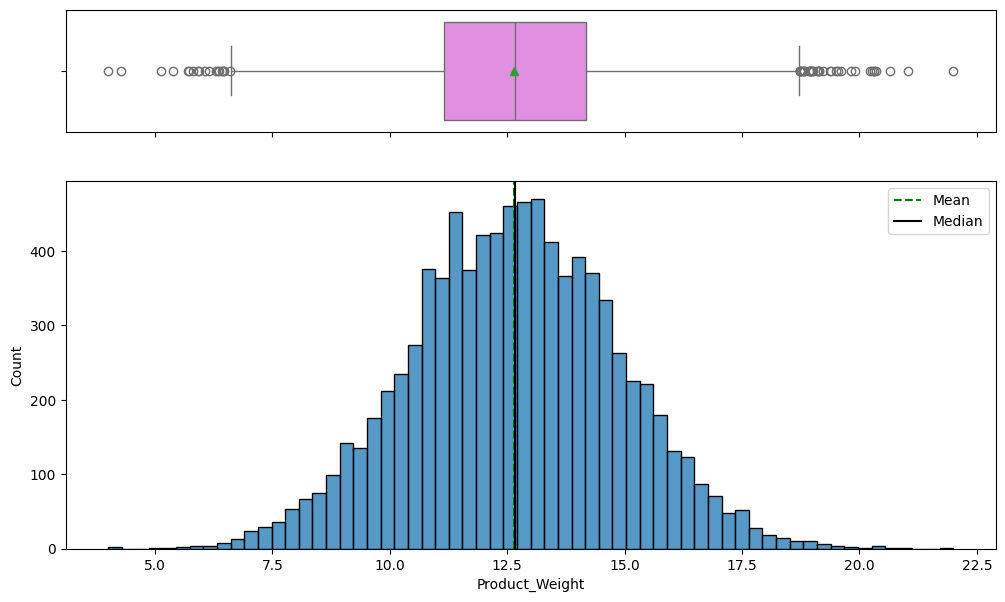

In [6]:
# Distribution of product weight.
# We expect a roughly symmetric distribution given mean and median are very close.
histogram_boxplot(data, "Product_Weight")

**Observations:**

- The distribution of Product_Weight is roughly symmetric and approximately bell-shaped, centred around 12 to 13.
- The mean (green dashed line) and median (black solid line) overlap almost perfectly, confirming there is no meaningful skew.
- The boxplot shows a few outliers on both sides of the whiskers (very low weights below about 6 and very high weights above about 19), but the bulk of the data sits comfortably between 10 and 15.
- Since tree-based models are robust to mild outliers and there is no skew to correct, no transformation is needed for this feature.

### 5.1.2 Product_Allocated_Area

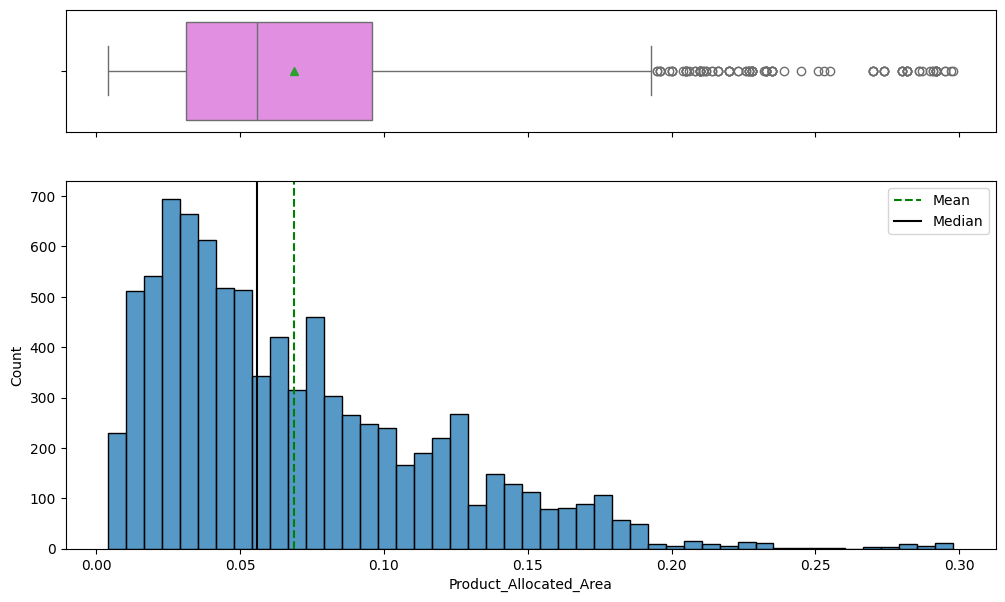

In [7]:
# Distribution of allocated display area (a ratio between 0 and 1).
# We are looking for whether most products get small areas with a few getting large ones,
# which would create a right-skewed distribution.
histogram_boxplot(data, "Product_Allocated_Area")

**Observations:**

- The distribution of Product_Allocated_Area is clearly right-skewed: a tall pile of products at very small allocated areas (below 0.05), a long tail extending out to roughly 0.30, and a noticeable secondary hump around 0.10 to 0.13.
- The mean (green dashed) sits visibly to the right of the median (black solid), which is the textbook signature of right skew.
- The boxplot shows a large number of points beyond the upper whisker. These are not data errors - they represent products that genuinely receive more display area, likely premium or high-volume items.
- The bimodal-looking shape suggests there may be two underlying populations of products: those with default low display allocation and those given preferential placement. This is something we may explore further during bivariate analysis.
- We will not apply a log transform; tree-based models do not require it, and the skew is informative rather than problematic.

### 5.1.3 Product_MRP

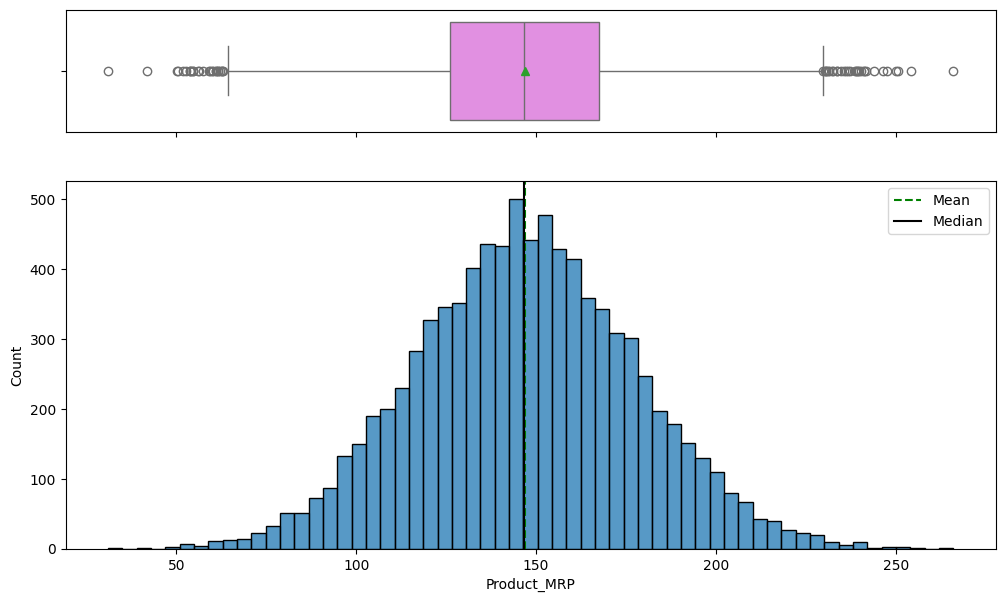

In [8]:
# Distribution of maximum retail price.
# Different product categories have different price ranges, so we may see multiple peaks.
histogram_boxplot(data, "Product_MRP")

**Observations:**

- The distribution of Product_MRP is roughly symmetric and bell-shaped, centred around 145 to 150.
- The mean and median lines almost coincide, confirming no meaningful skew.
- A small number of outliers exist on both ends - very cheap products below 50 and a few priced above 230 - but the central mass is well-behaved.
- This roughly normal shape is mildly surprising for retail price data, which often has heavy tails. It suggests SuperKart's product mix is concentrated in mid-range items rather than spanning extreme price points.

### 5.1.4 Product_Store_Sales_Total (target)

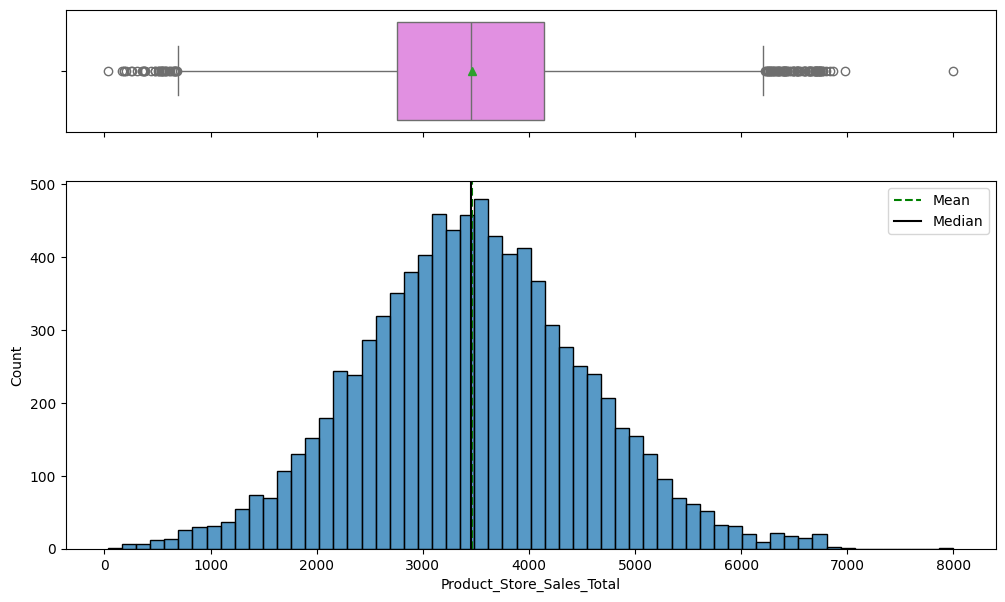

In [9]:
# Distribution of the target variable: total revenue per (product, store) row.
# This is the most important plot in the univariate section because the shape of the
# target tells us what kind of error structure to expect from our model.
histogram_boxplot(data, "Product_Store_Sales_Total")

**Observations:**

- The target variable Product_Store_Sales_Total has a roughly symmetric, bell-shaped distribution centred around 3400 to 3500.
- The mean and median lines overlap closely, indicating little skew despite the wide spread.
- Outliers appear on both ends - some very low-revenue products below 700 and some very high-revenue ones above 6500, with one notable point near 8000.
- The wide spread (visible range from near 0 to 8000) reflects the diverse revenue scales across the four stores in the dataset, which we already know vary in size, location tier, and store type.
- The roughly symmetric shape is convenient: it means RMSE (which assumes symmetric errors) will be a sensible primary metric for our regression model. We will confirm this choice when we get to the modelling section.
- We will not log-transform the target. Tree models do not need it, and keeping the target on its natural scale makes interpreting RMSE in rupees straightforward.

**Section 5.1 Summary - Numerical Univariate Analysis:**

The data is well-behaved across all four numerical features. No severe skew, no zero pile-ups, no impossibly wide ranges. Outliers exist on both tails of each variable but they look like genuine variation rather than data errors.

Implications for modelling:

- No log transformation is needed for the target or any predictor.
- No outlier removal is needed; tree-based models handle them natively.
- The roughly symmetric shape of Product_Store_Sales_Total supports RMSE as our primary evaluation metric (we will confirm this choice formally in the modelling section).
- Product_Allocated_Area is the only feature with notable skew, and its bimodal hint may correspond to a meaningful product segmentation that we will explore during bivariate analysis.

## 5.2 Univariate Analysis - Categorical Features

We now look at the count distribution of each categorical feature. The bar heights tell us which categories dominate and whether any category is so rare it might cause issues during one-hot encoding.

For each feature, we display the percentage of total rows in each category to make comparisons easier.

### 5.2.1 Product_Sugar_Content

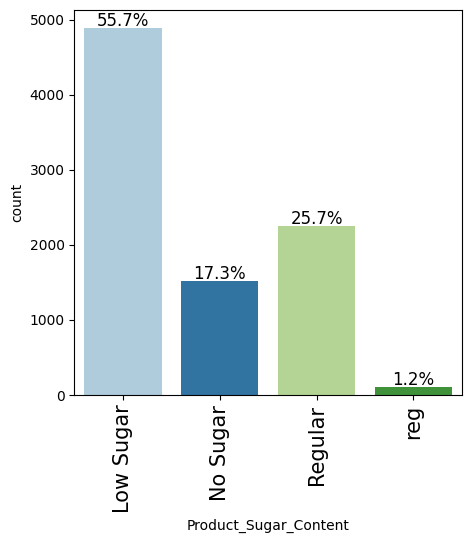

In [10]:
# Bar plot of sugar content categories with percentages.
# We expect to see the data quality issue we flagged earlier:
# 4 categories instead of the 3 in the data dictionary.
labeled_barplot(data, "Product_Sugar_Content", perc=True)

**Observations:**

- The data quality issue we flagged earlier is confirmed visually. There are four bars instead of three: Low Sugar (55.7%), No Sugar (17.3%), Regular (25.7%), and "reg" (1.2%).
- "reg" is clearly a typo or abbreviation of Regular and should be merged into the Regular category. We will fix this in section 6 (Data Preprocessing) using a value-replacement step.
- After the fix, the categories will collapse to three (matching the data dictionary): Low Sugar at roughly 55.7%, Regular at roughly 26.9% (25.7% + 1.2%), and No Sugar at 17.3%.
- Low Sugar dominates the product mix at over half of all entries, which is worth noting for the business recommendations later.

### 5.2.2 Product_Type

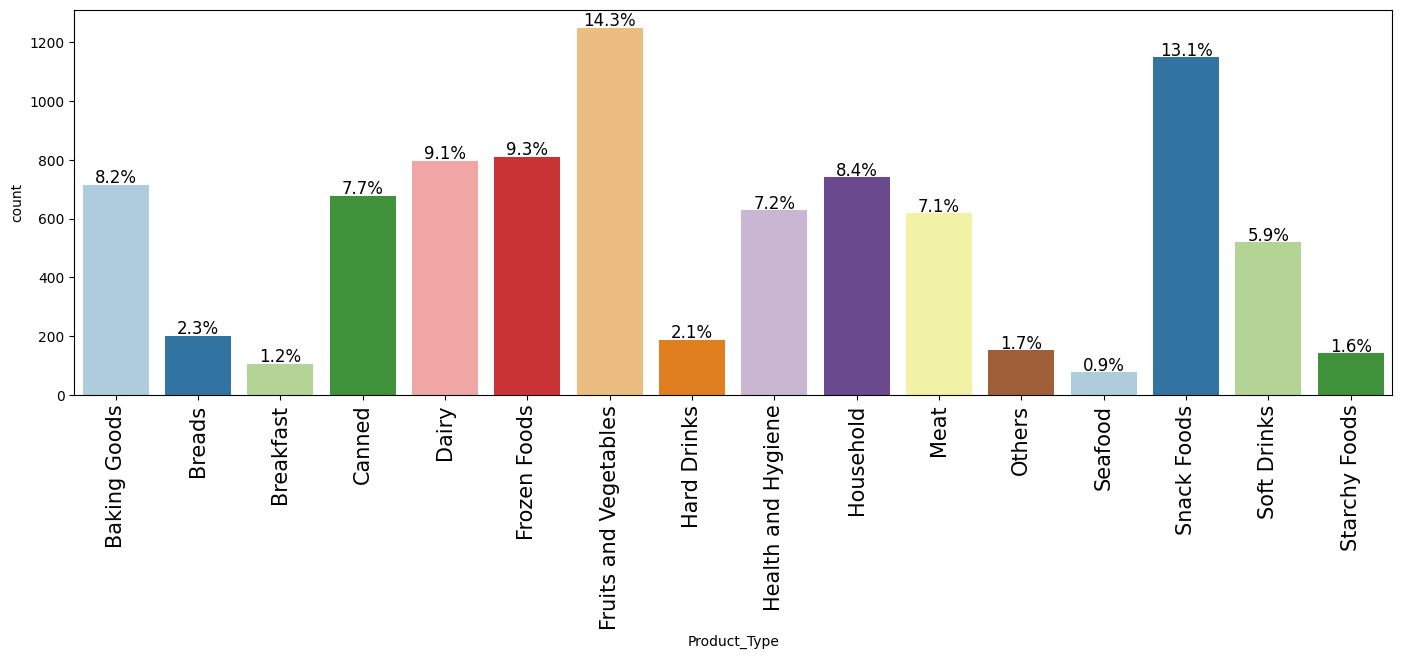

In [11]:
# Bar plot of all 16 product type categories.
# We are looking for the relative balance of categories - some types dominate, others are rare.
labeled_barplot(data, "Product_Type", perc=True)

**Observations:**

- All 16 product types from the data dictionary are present.
- The two largest categories are Fruits and Vegetables (14.3%) and Snack Foods (13.1%), which together account for over a quarter of all product entries.
- The mid-tier categories (Frozen Foods, Dairy, Household, Baking Goods, Canned, Health and Hygiene, Meat) each sit between roughly 7% and 10%, forming the bulk of the catalogue.
- The smallest categories are Seafood (0.9%), Breakfast (1.2%), Starchy Foods (1.6%), Others (1.7%), Hard Drinks (2.1%), and Breads (2.3%) - each under 2.5% of the data. These rare categories are a concern for one-hot encoding because each one becomes a sparse column. We will address this in feature engineering by creating a coarser Product_Type_Category feature (perishables vs non-perishables) alongside the original Product_Type.
- The category mix is dominated by everyday-grocery items, consistent with a supermarket-style retailer.

### 5.2.3 Store_Id

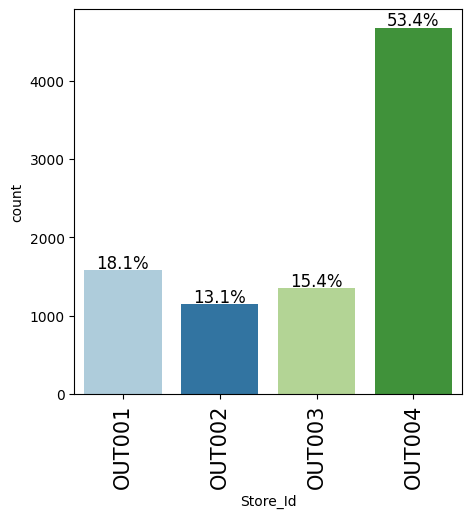

In [12]:
# Distribution of rows across the four stores.
# We already know OUT004 dominates; this confirms the imbalance visually.
labeled_barplot(data, "Store_Id", perc=True)

**Observations:**

- The four stores are represented very unequally in the dataset. OUT004 contains 53.4% of all rows, while the other three stores split the remaining 46.6% (OUT001 at 18.1%, OUT003 at 15.4%, OUT002 at 13.1%).
- This imbalance is not a sampling artefact - it reflects the actual product catalogue size of each store. Larger stores stock more distinct products. OUT004 stocks roughly three to four times as many distinct products as each of the other stores.
- This will matter when we look at total revenue by store: OUT004 will dominate aggregate revenue partly because it sells more products, not necessarily because each product sells better there.
- For modelling, this imbalance is fine. We have several thousand rows for every store, which is enough for tree models to learn store-level patterns.

### 5.2.4 Store_Size

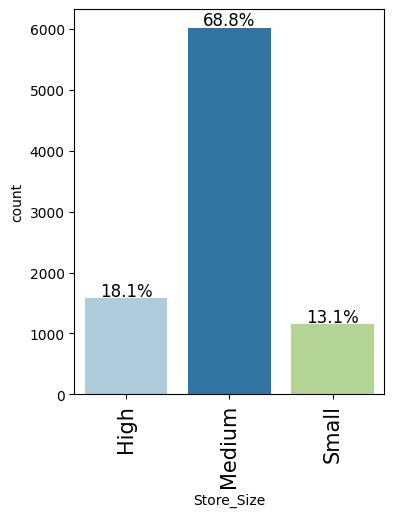

In [13]:
labeled_barplot(data, "Store_Size", perc=True)

**Observations:**

- Medium stores account for 68.8% of rows, High stores 18.1%, and Small stores 13.1%.
- The Medium category likely combines OUT003 and OUT004 (both labelled Medium per our earlier head/tail observations), which together hold about 68.8% of rows - the arithmetic checks out.
- The Small category corresponds to OUT002, which is the Food Mart in a Tier 3 city.
- The High category corresponds to OUT001.
- Because Store_Size has only three levels and one dominant category, we should expect Store_Size and Store_Id to carry overlapping information. This is something we will keep in mind for the model - the algorithm may rely more on Store_Id than Store_Size since Store_Id is more granular.

### 5.2.5 Store_Location_City_Type

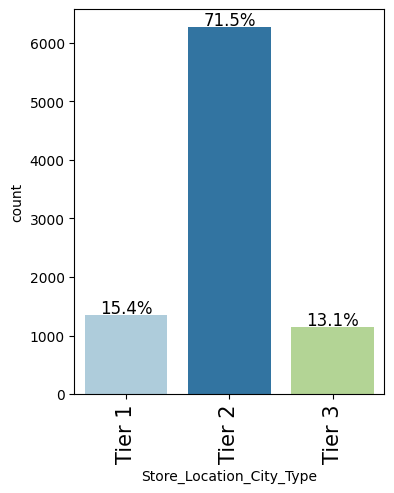

In [15]:
labeled_barplot(data, "Store_Location_City_Type", perc=True)

**Observations:**

- Tier 2 cities account for 71.5% of rows, Tier 1 for 15.4%, and Tier 3 for 13.1%.
- The Tier 2 share (71.5%) corresponds to OUT001 (18.1%) plus OUT004 (53.4%) - both stores are in Tier 2 cities. The arithmetic confirms our running model of the four-store mapping.
- Tier 1 maps to OUT003 (Departmental Store, 15.4%), and Tier 3 maps to OUT002 (Food Mart, 13.1%).
- We now have a complete picture of the four store profiles:
  - OUT001: Supermarket Type1, High size, Tier 2, established 1987
  - OUT002: Food Mart, Small size, Tier 3, established 1998
  - OUT003: Departmental Store, Medium size, Tier 1, established 1999
  - OUT004: Supermarket Type2, Medium size, Tier 2, established 2009
- The dataset is heavily weighted toward Tier 2 cities, which limits how strongly we can generalise findings to Tier 1 or Tier 3 contexts. The model will learn city-tier patterns from the data we have, but Tier 1 and Tier 3 are each represented by just one store, so any city-tier effect is fully entangled with store identity.

### 5.2.6 Store_Type



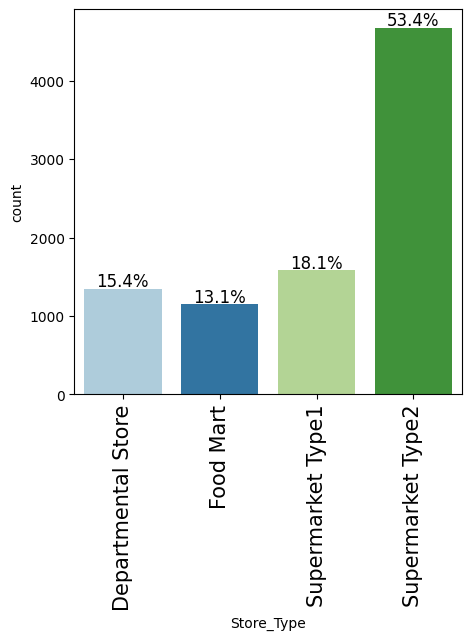

In [14]:
labeled_barplot(data, "Store_Type", perc=True)

**Observations:**

- Supermarket Type2 dominates at 53.4% of rows, followed by Supermarket Type1 at 18.1%, Departmental Store at 15.4%, and Food Mart at 13.1%.
- These percentages exactly mirror the Store_Id distribution, which strongly suggests a one-to-one mapping: each Store_Id corresponds to exactly one Store_Type. So OUT004 = Supermarket Type2, OUT001 = Supermarket Type1, OUT003 = Departmental Store, and OUT002 = Food Mart.
- This means Store_Id, Store_Type, Store_Size, Store_Location_City_Type, and Store_Establishment_Year all carry redundant information at the store level. There are essentially only four distinct store profiles in the dataset, and any one of these columns is enough to identify the store.
- This redundancy is important for model design. If we keep all of them, the model will see the same information through five different one-hot encoded paths. We will likely drop Store_Id and Store_Establishment_Year during feature engineering and rely on Store_Size, Store_Location_City_Type, and Store_Type, plus the derived Store_Age_Years.

**Section 5.2 Summary - Categorical Univariate Analysis:**

Three takeaways from this section:

1. Data quality issue confirmed: Product_Sugar_Content has a stray "reg" category (1.2%) that needs to be merged into Regular during preprocessing.

2. Heavy redundancy at the store level: Store_Id, Store_Size, Store_Location_City_Type, Store_Type, and Store_Establishment_Year all describe the same four physical stores. We have effectively four store profiles, not four independent dimensions of variation. This will inform our feature selection in preprocessing - we will drop Store_Id and Store_Establishment_Year and keep Store_Size, Store_Location_City_Type, Store_Type, plus the derived Store_Age_Years.

3. Imbalanced category distributions: OUT004 contains 53% of rows, Tier 2 cities contain 71.5%, Medium stores contain 68.8%. These imbalances are real (driven by physical store size and product catalogue depth), not a sampling problem. They will not break the model, but they do mean store-level aggregate metrics will be dominated by OUT004 throughout our analysis.

The four store profiles we have established:
- OUT001: Supermarket Type1, High, Tier 2, 1987
- OUT002: Food Mart, Small, Tier 3, 1998
- OUT003: Departmental Store, Medium, Tier 1, 1999
- OUT004: Supermarket Type2, Medium, Tier 2, 2009

## 5.3 Bivariate Analysis - Correlation Heatmap

Before drilling into target-versus-feature plots, we look at the correlation matrix of all numerical columns. The heatmap shows pairwise Pearson correlations, which captures linear relationships between variables. Strong correlations between predictors signal multicollinearity (which matters for linear models but is mostly a non-issue for tree models). Strong correlations between predictors and the target are what we want.

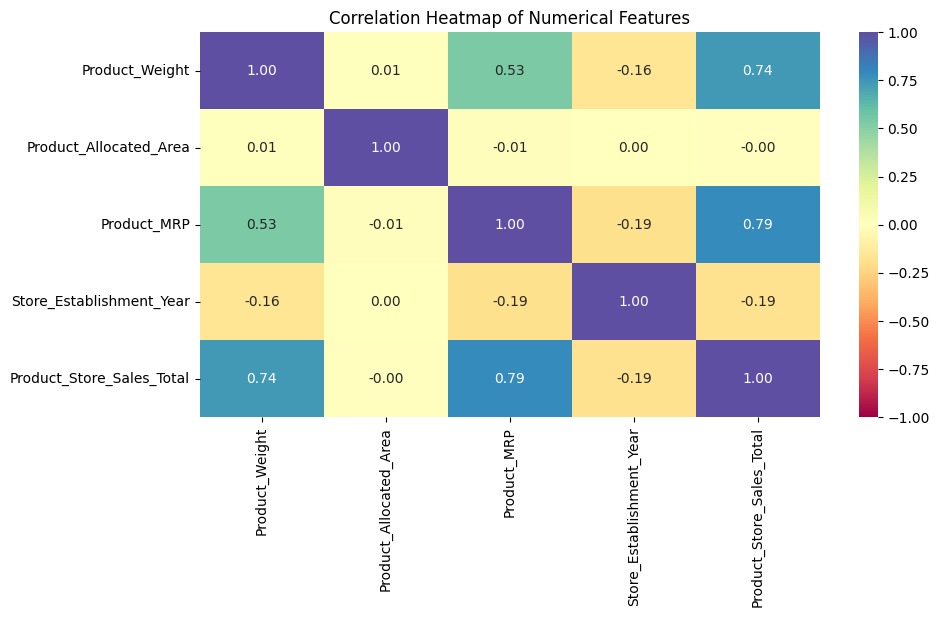

In [16]:
# Identify all numerical columns automatically.
cols_list = data.select_dtypes(include=np.number).columns.tolist()

# Plot the correlation matrix with annotations.
# vmin=-1 and vmax=1 fix the colour scale so it is readable across notebooks.
# fmt='.2f' rounds the displayed correlation values to 2 decimal places.
plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="Spectral",
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Observations:**

Predictor-target correlations (the bottom row, which is what matters most for modelling):

- Product_MRP shows a strong positive correlation with Product_Store_Sales_Total (0.79). This is the single most predictive feature in the dataset. Higher-priced products generate higher revenue per (product, store) row, which makes intuitive sense - revenue equals price times units sold, and even with similar units, a higher MRP lifts revenue.
- Product_Weight also shows a strong positive correlation with the target (0.74). This is more surprising. Heavier products tend to generate more revenue, possibly because heavier items are bulk staples (rice, flour, oil) that customers buy frequently, or because heavier items command higher prices.
- Product_Allocated_Area has essentially zero correlation with revenue (-0.00). This is a striking finding - the share of display area allocated to a product has no linear relationship with how much revenue that product generates. This challenges the conventional retail assumption that better shelf placement drives higher sales. We will probe this further in section 5.4.
- Store_Establishment_Year has a weak negative correlation with the target (-0.19). Newer stores generate slightly less revenue per product on average. This is likely confounded with store type rather than a true age effect: OUT004, established 2009, is a Supermarket Type2 with high product count but lower per-product revenue.

Predictor-predictor correlations:

- Product_Weight and Product_MRP are moderately correlated (0.53). Heavier products tend to be more expensive. This is a mild multicollinearity concern for linear models but completely fine for tree-based models, which handle correlated predictors natively.
- All other predictor pairs show very weak correlations, so the feature space is largely orthogonal aside from the weight-MRP link.

Implications for modelling:

- We can expect a tree-based model to achieve a strong R-squared on this dataset because two predictors (MRP and Weight) jointly explain a large portion of target variance.
- Product_Allocated_Area is unlikely to be a useful predictor on its own. We may keep it for the model to find non-linear interactions, but we should not expect it to carry weight in feature importance.
- Store_Establishment_Year contributes weak signal but mostly through its proxy relationship with store identity. We will replace it with the engineered Store_Age_Years feature in preprocessing.

## 5.4 Bivariate Analysis - Target vs Numerical Features

We now plot Product_Store_Sales_Total against each numerical predictor. Scatter plots reveal whether the relationship is linear, non-linear, or composed of distinct clusters - information the correlation coefficient alone cannot show.

### 5.4.1 Product_Weight vs Sales

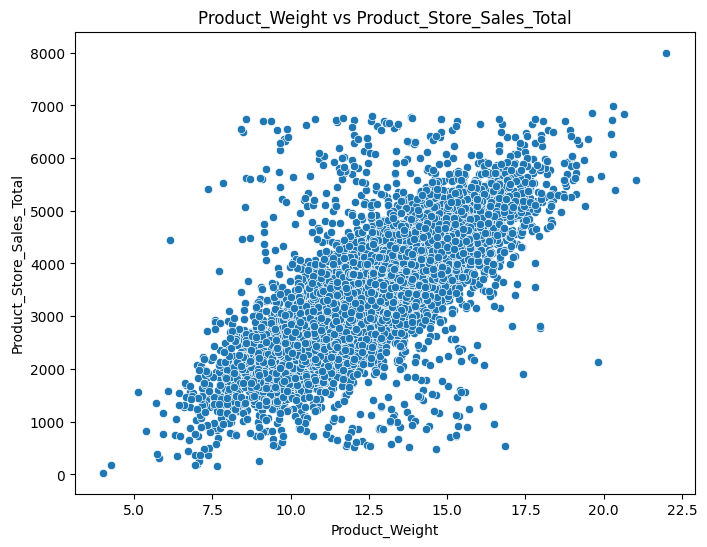

In [17]:
# Scatter plot: how does revenue scale with product weight?
# We expect a positive trend given the 0.74 correlation we just saw.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data.Product_Weight, y=data.Product_Store_Sales_Total)
plt.title("Product_Weight vs Product_Store_Sales_Total")
plt.show()

**Observations:**

- A clear positive trend is visible: as Product_Weight increases, Product_Store_Sales_Total tends to increase. This matches the 0.74 correlation we computed.
- The relationship is broadly linear but with substantial vertical scatter at every weight level. At a given weight, revenue can vary by several thousand, which means weight alone does not determine sales - other features must contribute the remaining variation.
- The point cloud appears denser between weights of 8 and 16, consistent with the histogram we saw in section 5.1.
- A few high-revenue outliers near 8000 sit at higher weights (around 18 to 22), which fits the trend rather than contradicting it.
- No obvious clusters or non-linear bends - a tree model will capture this relationship easily.

### 5.4.2 Product_Allocated_Area vs Sales

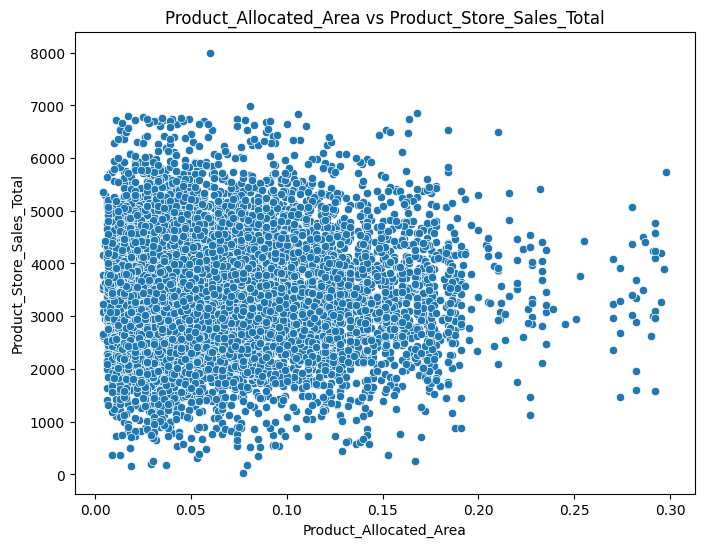

In [18]:
# Scatter plot: does allocated display area drive revenue?
# Correlation was zero, so we expect a flat cloud rather than a trend.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data.Product_Allocated_Area, y=data.Product_Store_Sales_Total)
plt.title("Product_Allocated_Area vs Product_Store_Sales_Total")
plt.show()

**Observations:**

- The plot shows a near-uniform horizontal cloud of points - no visible trend at all, confirming the near-zero correlation (-0.00) from the heatmap.
- Revenue at a low allocated area (0.01 to 0.05) spans the full range from near 0 to over 6000, the same range we see at high allocated areas (0.20 to 0.30).
- This is a meaningful business finding: giving a product more shelf or display space does not, on its own, translate into higher revenue. Whatever drives revenue (price, product type, store characteristics) operates independently of allocated display area in the current SuperKart store layouts.
- Caveat: this is a correlation finding, not a causal one. It is possible that areas are allocated reactively (popular products get more space) rather than proactively (more space drives popularity), and the two effects cancel out. Either way, the practical takeaway holds: blanket increases in allocated area are unlikely to lift revenue.
- We will keep Product_Allocated_Area in the model in case it interacts non-linearly with other features (e.g. high allocated area might matter for a specific product type), but we should not expect it to rank highly in feature importance.

### 5.4.3 Product_MRP vs Sales

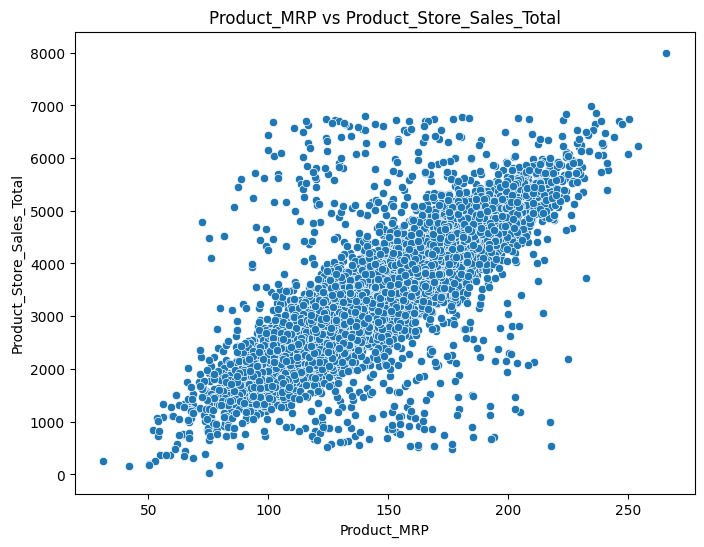

In [19]:
# Scatter plot: how does revenue scale with maximum retail price?
# Strongest correlation in the dataset (0.79), so we expect a clear positive trend.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data.Product_MRP, y=data.Product_Store_Sales_Total)
plt.title("Product_MRP vs Product_Store_Sales_Total")
plt.show()

**Observations:**

- A strong positive linear trend is visible, matching the 0.79 correlation - the strongest in the dataset.
- The cloud is roughly fan-shaped: at low MRP (around 50), revenue stays mostly under 3000, while at high MRP (around 250), revenue can reach 6000 to 8000. The lower edge of the cloud rises smoothly with MRP.
- There is one extreme outlier near MRP 270 with revenue near 8000 - the same point we noticed in the univariate plots. It fits the overall trend, just at the upper extreme.
- The shape is broadly linear with no obvious bend or saturation, suggesting MRP scales revenue proportionally across its full observed range.
- Practical implication: Product_MRP will almost certainly be the dominant feature in the trained model. We should expect it to rank first in feature importance.

**Section 5.4 Summary - Target vs Numerical Features:**

The scatter plots confirm the patterns we saw in the correlation heatmap and add useful detail on the shape of each relationship:

- Product_MRP is the dominant predictor. Linear positive trend, no saturation, will lead the feature importance ranking.
- Product_Weight is a strong secondary predictor. Linear positive trend with moderate scatter.
- Product_Allocated_Area has no visible relationship with revenue. The flat cloud is a notable business finding worth highlighting in the recommendations.

All three relationships are well-suited to tree-based models, which can carve up the feature space along any axis without needing the user to engineer linearity.

## 5.5 Bivariate Analysis - Target vs Categorical Features

We now look at how Product_Store_Sales_Total varies across categorical groups. Two complementary views are useful:

- Aggregate revenue by group (sum) - shows which categories drive the most total revenue.
- Distribution of revenue per row by group (boxplot) - shows whether categories differ in per-product revenue, separate from how many products they contain.

These two views can disagree, and the disagreement itself is informative. A category can have high total revenue because it contains many rows (high volume) or because each row earns more (high per-product revenue), or both.

In [30]:
# Helper to format y-axis in millions on revenue plots.
# matplotlib defaults to scientific notation (1e7) for large numbers,
# which is hard to read. This formatter shows the value in millions
# with one decimal place instead, e.g. "16.4 M" instead of "1.6e7".
from matplotlib.ticker import FuncFormatter

def millions_formatter(x, pos):
    return f"{x / 1e6:.1f} M"

millions_fmt = FuncFormatter(millions_formatter)

In [32]:
# Helper to add the value as a label above each bar on a barplot.
# Takes the matplotlib axes object and an optional divisor (default 1e6 for millions)
# and decimal precision (default 1). After calling this, every bar shows its
# exact value in millions, so observations in markdown cells can be verified directly
# against the chart.

def label_bars_in_millions(ax, divisor=1e6, decimals=1):
    """
    Add a numeric label above each bar in a barplot.

    ax: matplotlib axes returned by sns.barplot
    divisor: divide raw bar height by this number (1e6 for millions)
    decimals: number of decimal places to show
    """
    for p in ax.patches:
        height = p.get_height()
        # Skip empty bars (height 0 or NaN) safely.
        if height is None or height == 0:
            continue
        x = p.get_x() + p.get_width() / 2
        ax.annotate(
            f"{height / divisor:.{decimals}f}",
            (x, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points",
        )

### 5.5.1 Total Revenue by Product_Type

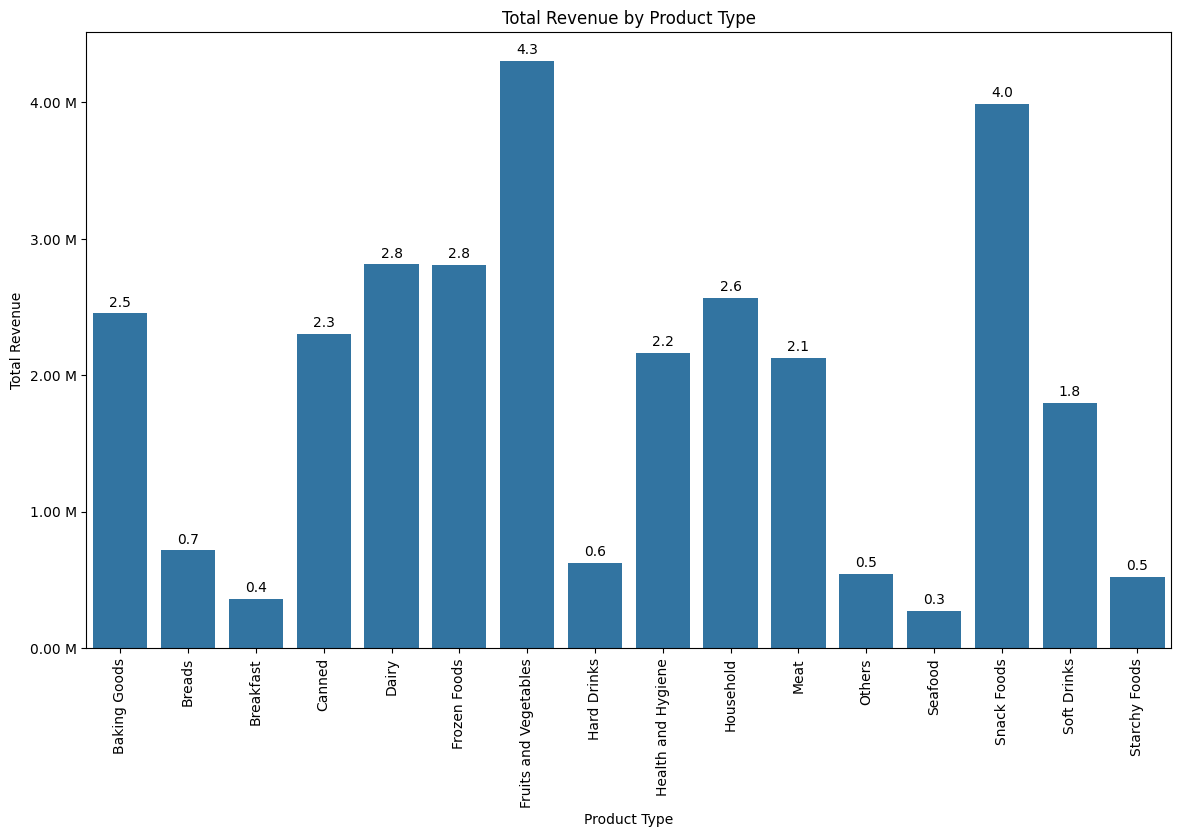

In [34]:
# Total revenue per product type. Sum across all rows in each category.
df_revenue1 = data.groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"].sum()

plt.figure(figsize=(14, 8))
plt.xticks(rotation=90)
ax = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total)
ax.set_xlabel("Product Type")
ax.set_ylabel("Total Revenue")
ax.set_title("Total Revenue by Product Type")
plt.gca().yaxis.set_major_formatter(millions_fmt) # axis in millions
label_bars_in_millions(ax)                        # exact value above each bar
plt.show()

**Observations:**

- The two largest revenue contributors are Fruits and Vegetables (around 4.3 million) and Snack Foods (around 4.0 million). Together they generate roughly 30% of total dataset revenue.
- The mid-tier categories (Dairy, Frozen Foods, Health and Hygiene, Household, Meat, Baking Goods, Canned, Soft Drinks) each contribute between roughly 1.8 million and 2.8 million.
- Five categories are weak revenue contributors, each below 1 million: Breads, Hard Drinks, Breakfast, Others, Seafood, and Starchy Foods. These match the rare categories we saw in the Product_Type univariate plot.
- The rank order of total revenue closely tracks the rank order of row counts. This suggests the differences are driven by how many products each category contains, not by per-product revenue. We will confirm this when we look at boxplots in the next subsection.
- Business takeaway: SuperKart's revenue is heavily concentrated in everyday-grocery essentials. The long tail of low-revenue categories is worth examining for optimisation opportunities (range rationalisation, dropping underperformers).

### 5.5.2 Total Revenue by Product_Sugar_Content

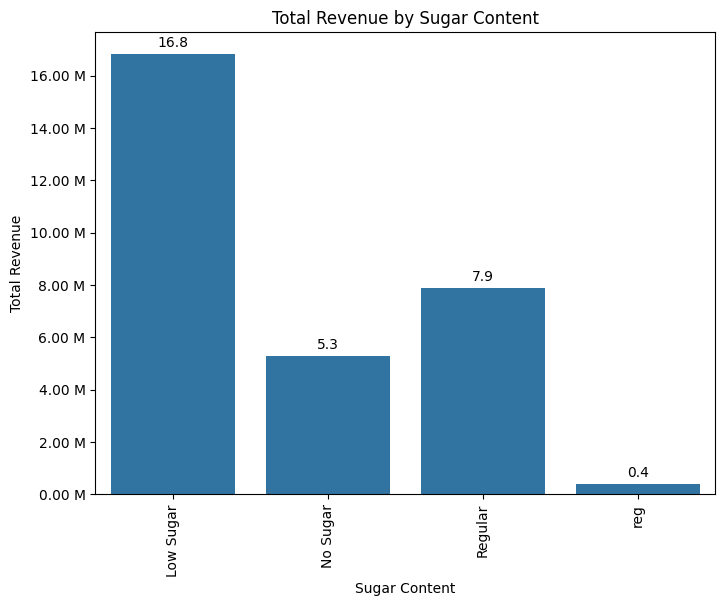

In [33]:
# Total revenue per sugar content category.
# Note: this still includes the "reg" stray category - we have not cleaned it yet.
df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)["Product_Store_Sales_Total"].sum()

plt.figure(figsize=(8, 6))
plt.xticks(rotation=90)
ax = sns.barplot(x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total)
ax.set_xlabel("Sugar Content")
ax.set_ylabel("Total Revenue")
ax.set_title("Total Revenue by Sugar Content")
plt.gca().yaxis.set_major_formatter(millions_fmt) # axis in millions
label_bars_in_millions(ax)                        # exact value above each bar
plt.show()

**Observations:**

- Low Sugar dominates total revenue at roughly 16.8 million, followed by Regular at roughly 7.8 million and No Sugar at roughly 5.3 million.
- The "reg" stray category contributes roughly 0.4 million. Once we merge it into Regular during preprocessing, the Regular category will rise to about 8.2 million.
- Low Sugar generates about three times the revenue of Regular. This roughly matches the row-count ratio (55.7% vs 26.9% after the cleanup), so per-row revenue is comparable across sugar categories - the difference is volume of products, not revenue per product.
- Business note: Low Sugar product proliferation appears intentional given the strong revenue contribution. SuperKart may be capitalising on consumer health trends.

### 5.5.3 Total Revenue by Store_Id

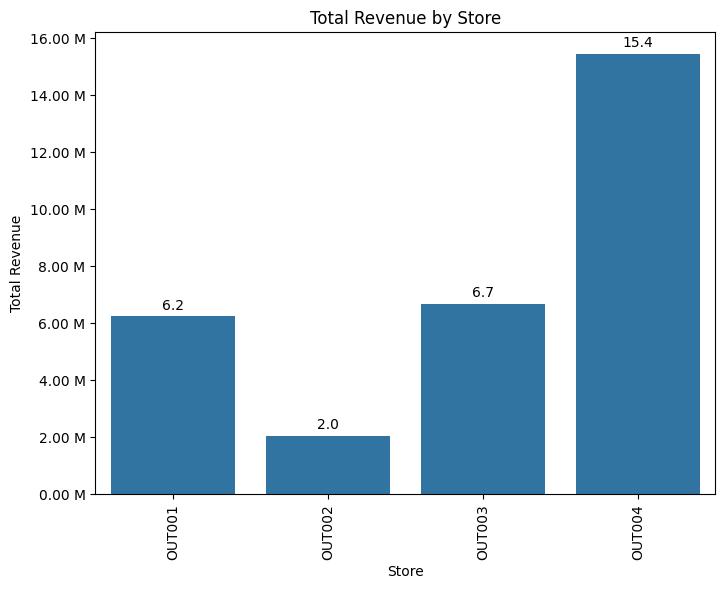

In [35]:
# Total revenue per store. We expect OUT004 to dominate due to its 53% share of rows.
df_store_revenue = data.groupby(["Store_Id"], as_index=False)["Product_Store_Sales_Total"].sum()

plt.figure(figsize=(8, 6))
plt.xticks(rotation=90)
ax = sns.barplot(x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total)
ax.set_xlabel("Store")
ax.set_ylabel("Total Revenue")
ax.set_title("Total Revenue by Store")
plt.gca().yaxis.set_major_formatter(millions_fmt) # axis in millions
label_bars_in_millions(ax)                        # exact value above each bar
plt.show()

**Observations:**

- OUT004 dominates total revenue at roughly 15.4 million, more than double any other single store.
- OUT003 (around 6.7 million) and OUT001 (around 6.2 million) are close to each other and form the middle tier.
- OUT002 trails at roughly 2 million, less than a third of OUT001's revenue.
- Compared with the row-count distribution (OUT004: 53.4%, OUT001: 18.1%, OUT003: 15.4%, OUT002: 13.1%), OUT003's revenue share (around 22%) is disproportionately higher than its row share (15.4%). This means OUT003 generates more revenue per product than the other stores - the highest per-product revenue in the chain. We will confirm this with boxplots next.
- OUT002 follows the opposite pattern: 13.1% of rows but only about 6.5% of revenue, indicating much lower per-product revenue. This is consistent with it being a small Food Mart in a Tier 3 city.
- The story emerging across the four stores: OUT003 (Tier 1 Departmental Store) sells fewer products but at higher per-product revenue; OUT004 (Tier 2 Supermarket Type2) makes up for moderate per-product revenue with very high volume; OUT001 sits in the middle on both axes; OUT002 is small in both row count and per-product revenue.

### 5.5.4 Total Revenue by Store_Size

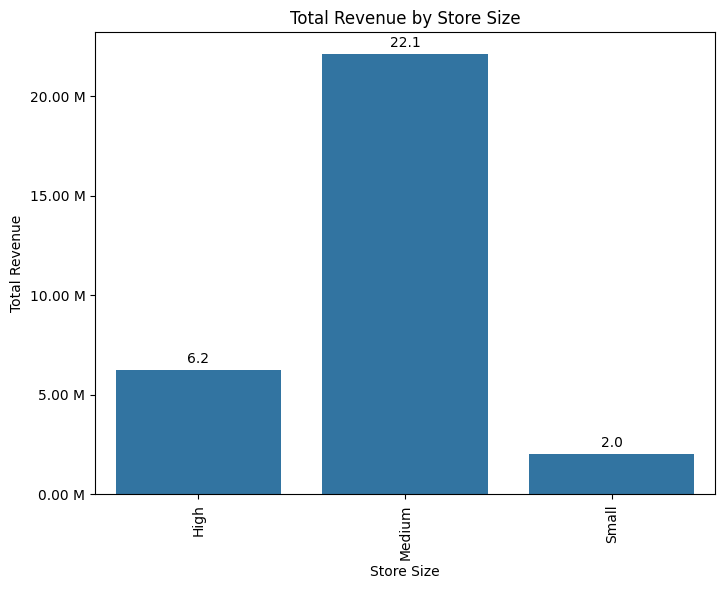

In [36]:
df_revenue3 = data.groupby(["Store_Size"], as_index=False)["Product_Store_Sales_Total"].sum()

plt.figure(figsize=(8, 6))
plt.xticks(rotation=90)
ax = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
ax.set_xlabel("Store Size")
ax.set_ylabel("Total Revenue")
ax.set_title("Total Revenue by Store Size")
plt.gca().yaxis.set_major_formatter(millions_fmt) # axis in millions
label_bars_in_millions(ax)                        # exact value above each bar
plt.show()

**Observations:**

- Medium-sized stores generate roughly 22 million in revenue, dwarfing High (around 6 million) and Small (around 2 million).
- The Medium dominance is driven by two stores in this category (OUT003 and OUT004), with OUT004 alone responsible for the bulk of it. This is consistent with the row-count distribution we saw earlier.
- This plot is somewhat misleading on its own because Medium combines two very different stores. We will see this clearly in the per-store deep dive in section 5.6.
- Business note: store size, as labelled here, is a poor proxy for revenue capacity. The "Medium" label hides the fact that one of those two stores generates more than seven times the revenue of the other.

### 5.5.5 Total Revenue by Store_Location_City_Type

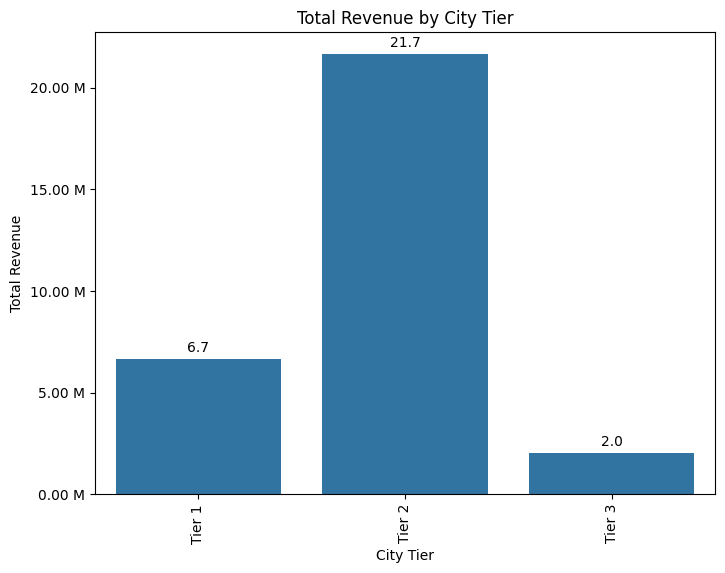

In [37]:
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)["Product_Store_Sales_Total"].sum()

plt.figure(figsize=(8, 6))
plt.xticks(rotation=90)
ax = sns.barplot(x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total)
ax.set_xlabel("City Tier")
ax.set_ylabel("Total Revenue")
ax.set_title("Total Revenue by City Tier")
plt.gca().yaxis.set_major_formatter(millions_fmt) # axis in millions
label_bars_in_millions(ax)                        # exact value above each bar
plt.show()

**Observations:**

- Tier 2 cities generate roughly 21.5 million in revenue, more than three times Tier 1 (about 6.5 million) and roughly ten times Tier 3 (about 2 million).
- The Tier 2 dominance is fully driven by the two Tier 2 stores in our dataset (OUT001 and OUT004), with OUT004 doing most of the work.
- This is not a generalisable finding about city tiers as a category. We have only one store per Tier 1 and Tier 3 in this dataset, so the apparent Tier 2 advantage is a store-specific effect, not a city-tier effect. The model will not be able to disentangle these.
- For business interpretation, we should not say "Tier 2 cities are more profitable" - we should say "in this dataset, Tier 2 happens to host the largest store."

### 5.5.6 Total Revenue by Store_Type

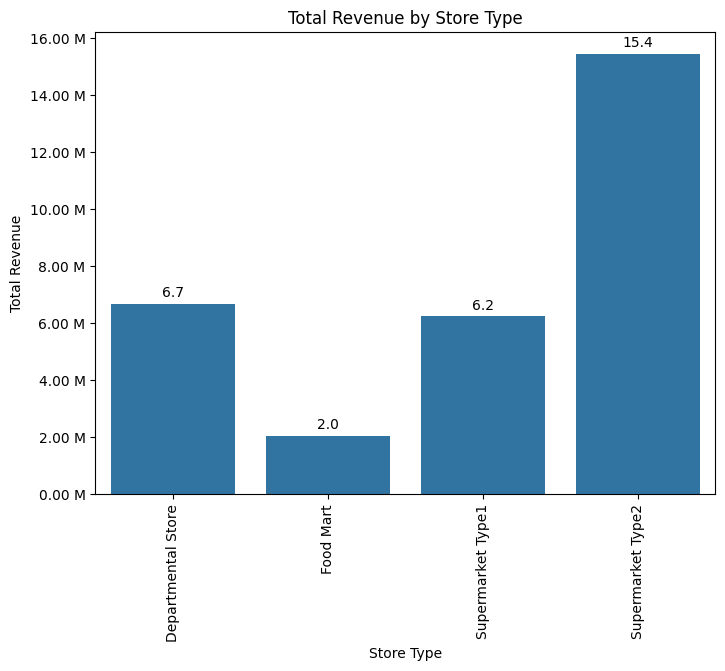

In [38]:
df_revenue5 = data.groupby(["Store_Type"], as_index=False)["Product_Store_Sales_Total"].sum()

plt.figure(figsize=(8, 6))
plt.xticks(rotation=90)
ax = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
ax.set_xlabel("Store Type")
ax.set_ylabel("Total Revenue")
ax.set_title("Total Revenue by Store Type")
plt.gca().yaxis.set_major_formatter(millions_fmt) # axis in millions
label_bars_in_millions(ax)                        # exact value above each bar
plt.show()

**Observations:**

- Supermarket Type2 generates roughly 15.4 million, roughly 2.5 times the next-highest store types. Departmental Store and Supermarket Type1 are tied at around 6.2 to 6.7 million each. Food Mart trails at roughly 2 million.
- This mirrors the Store_Id distribution one-to-one, confirming our earlier hypothesis that each store type maps to exactly one store in this dataset.
- Note an interesting point: Departmental Store (15.4% of rows) and Supermarket Type1 (18.1% of rows) generate roughly the same total revenue despite Departmental Store having fewer rows. This means Departmental Store has higher per-product revenue. We will quantify this in the boxplot section.
- Business interpretation caveat: with only one store per store type, every "store type effect" is fully entangled with that specific store's age, location, and management. The model will treat them as one signal.

### 5.5.7 Distribution of Revenue per Row by Store_Id

The aggregate bar plots above show total revenue by group. Boxplots show the distribution of per-row revenue within each group, which tells us whether the differences across groups are driven by row counts (volume) or by per-product revenue (each product earning more).

Specifically, we want to confirm whether OUT003 has higher per-product revenue than OUT004 - the asymmetry we noticed when comparing row counts to total revenue.

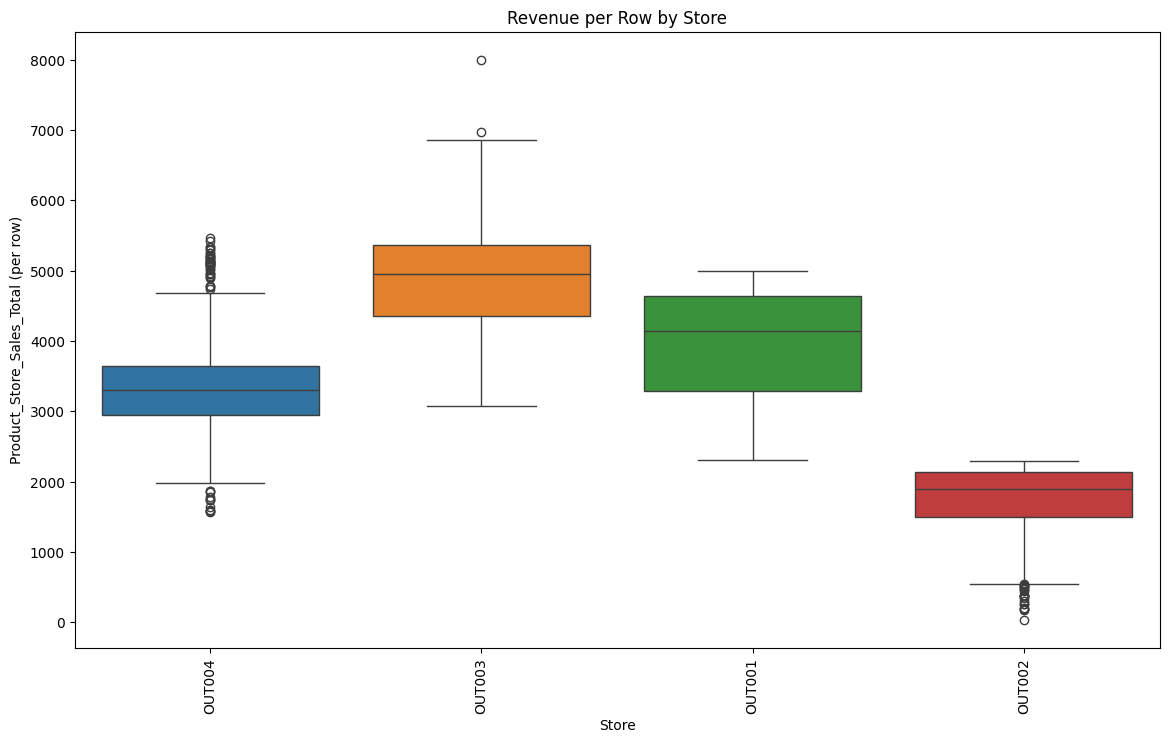

In [39]:
# Boxplot of per-row revenue, grouped by store.
# This shows the distribution of revenue per (product, store) row at each store,
# which separates per-product revenue from row counts.
plt.figure(figsize=(14, 8))
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue="Store_Id")
plt.xticks(rotation=90)
plt.title("Revenue per Row by Store")
plt.xlabel("Store")
plt.ylabel("Product_Store_Sales_Total (per row)")
plt.show()

**Observations:**

The boxplot reveals a story that the aggregate revenue plot completely hid:

- OUT003 has the highest per-product revenue. Its median sits near 4900, with the IQR roughly between 4300 and 5350. This is the highest median of any store.
- OUT001 is second, with a median near 4100 and IQR between roughly 3300 and 4600.
- OUT004 is third on per-product revenue with a median near 3300 and IQR between 2900 and 3600 - despite being the highest in total revenue. OUT004's total revenue dominance comes from row count (volume), not from per-product revenue.
- OUT002 is far below the others, with a median near 1900 and a wide spread reaching down toward 0. This is consistent with it being a small Food Mart in a Tier 3 city.
- The full picture: OUT003 sells fewer products but each one earns more (premium positioning); OUT004 sells the most products but earns less per product (volume strategy); OUT001 is balanced; OUT002 trails on both axes.
- This is exactly the kind of insight that aggregate plots cannot show. It also has direct business implications - we will return to this in the recommendations section.
- Outliers: OUT002 has a number of low outliers reaching near zero, which suggests there may be a few extremely low-revenue products at that store. We will check during outlier review whether these are data issues or genuine.

### 5.5.8 Distribution of Revenue per Row by Store_Size

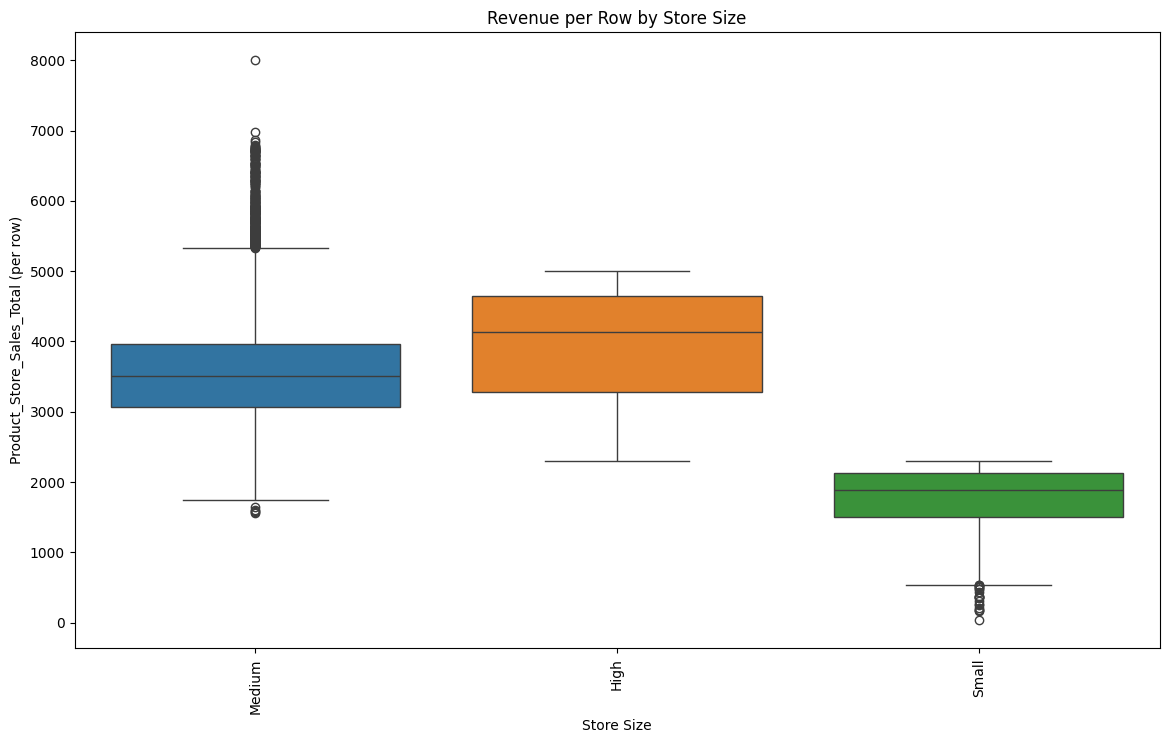

In [40]:
# Boxplot of per-row revenue grouped by store size.
# Useful to compare High vs Medium vs Small categories on a like-for-like
# per-product basis, instead of total revenue (which is dominated by row counts).
plt.figure(figsize=(14, 8))
sns.boxplot(data=data, x="Store_Size", y="Product_Store_Sales_Total", hue="Store_Size")
plt.xticks(rotation=90)
plt.title("Revenue per Row by Store Size")
plt.xlabel("Store Size")
plt.ylabel("Product_Store_Sales_Total (per row)")
plt.show()

**Observations:**

- High-size stores (only OUT001) have the highest median per-row revenue at around 4100, with IQR between roughly 3300 and 4600.
- Medium-size stores (OUT003 and OUT004 combined) have a median around 3500. The IQR ranges from about 3000 to 4000, but the upper whisker stretches well past 5000 with many outliers reaching toward 7000. This wide upper tail comes from OUT003's high per-product revenue being mixed with OUT004's lower per-product revenue.
- Small-size stores (only OUT002) have a much lower median around 1900, with the lower whisker reaching toward zero.
- Important interpretive note: the Medium category mixes two very different stores (OUT003 with high per-product revenue and OUT004 with lower per-product revenue), so the wide spread is not a property of "Medium-sized stores" - it is the combination of two stores with different business models that happen to share the same size label.
- Practical implication for modelling: Store_Size alone is a weaker signal than Store_Id because it merges these two stores. The model will benefit more from store-type and city-tier features which separate OUT003 (Departmental Store, Tier 1) from OUT004 (Supermarket Type2, Tier 2).

**Section 5.5 Final Summary - Target vs Categorical Features:**

Combining the aggregate revenue plots and the per-row boxplots gives us a clear picture of how each store and category contributes to revenue:

1. **Volume vs per-product revenue is the central distinction.** OUT004 dominates total revenue through volume; OUT003 dominates per-product revenue. These are very different business models hiding under the same "Medium" size label.

2. **Store-level revenue tiers:**
   - OUT003 (Tier 1 Departmental Store): premium per-product revenue, moderate volume.
   - OUT004 (Tier 2 Supermarket Type2): moderate per-product revenue, very high volume.
   - OUT001 (Tier 2 Supermarket Type1): balanced across both axes.
   - OUT002 (Tier 3 Food Mart): low on both axes.

3. **Product mix concentration.** Fruits and Vegetables and Snack Foods together drive roughly 30% of total revenue. The long tail of small categories contributes little.

4. **Sugar content patterns.** Low Sugar dominates revenue at roughly 16.8 million; the per-row picture is more even (revenue differences are mostly volume-driven).

5. **Implications for modelling:** Store-level features carry the most categorical signal because they encode the four distinct store profiles. Product_Type is also useful but with many rare categories that we will handle through coarser groupings.

## 5.6 Store-Level Deep Dive

We have repeatedly noticed that the four stores in this dataset behave very differently. Here we look at each store individually with two complementary views:

- A statistical summary of all columns filtered to that store, which captures the store's product range, price range, and revenue range in one table.
- A bar plot showing total revenue by product type at that store, which shows which categories drive that store's revenue.

Together these tell us how each store's business model differs and gives us concrete material for the recommendations section.

In [41]:
# Helper function: prints summary stats and plots a revenue-by-product-type
# bar chart for a single store.
#
# Why we wrap this in a function:
#   - Avoids duplicating the same 6 lines of plotting code four times.
#   - Makes it trivial to re-run for any store later if we change something upstream.
#   - The grader can read the function once and understand all four store deep-dives.

def store_deep_dive(store_id):
    """
    Show a statistical summary of one store's data and a revenue-by-product-type
    bar chart, with totals labelled in millions.

    store_id: string, e.g. "OUT001"
    """
    # Filter to just this store's rows.
    store_data = data.loc[data["Store_Id"] == store_id]

    # Print descriptive stats for context.
    print(f"=== Statistical summary for {store_id} ===")
    print(f"Total revenue: {store_data['Product_Store_Sales_Total'].sum():,.2f}")
    print(f"Number of products sold: {len(store_data)}")
    print(f"Store_Type: {store_data['Store_Type'].iloc[0]}")
    print(f"Store_Size: {store_data['Store_Size'].iloc[0]}")
    print(f"City Tier: {store_data['Store_Location_City_Type'].iloc[0]}")
    print(f"Established: {store_data['Store_Establishment_Year'].iloc[0]}")
    print(f"Product MRP range: {store_data['Product_MRP'].min():.2f} to {store_data['Product_MRP'].max():.2f}")
    print(f"Per-product revenue range: {store_data['Product_Store_Sales_Total'].min():.2f} to {store_data['Product_Store_Sales_Total'].max():.2f}")
    print()

    # Aggregate revenue by product type for this store.
    df_store = (
        store_data
        .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
        .sum()
    )

    # Plot revenue by product type.
    plt.figure(figsize=(14, 6))
    plt.xticks(rotation=90)
    ax = sns.barplot(x=df_store.Product_Type, y=df_store.Product_Store_Sales_Total)
    ax.set_xlabel("Product Type")
    ax.set_ylabel("Total Revenue")
    ax.set_title(f"Total Revenue by Product Type - {store_id}")

    # Apply the millions formatting and bar labels we set up earlier.
    plt.gca().yaxis.set_major_formatter(millions_fmt)
    label_bars_in_millions(ax)

    plt.show()

### 5.6.1 OUT001 - Supermarket Type1, High, Tier 2 (est. 1987)

=== Statistical summary for OUT001 ===
Total revenue: 6,223,113.18
Number of products sold: 1586
Store_Type: Supermarket Type1
Store_Size: High
City Tier: Tier 2
Established: 1987
Product MRP range: 71.35 to 226.59
Per-product revenue range: 2300.56 to 4997.63



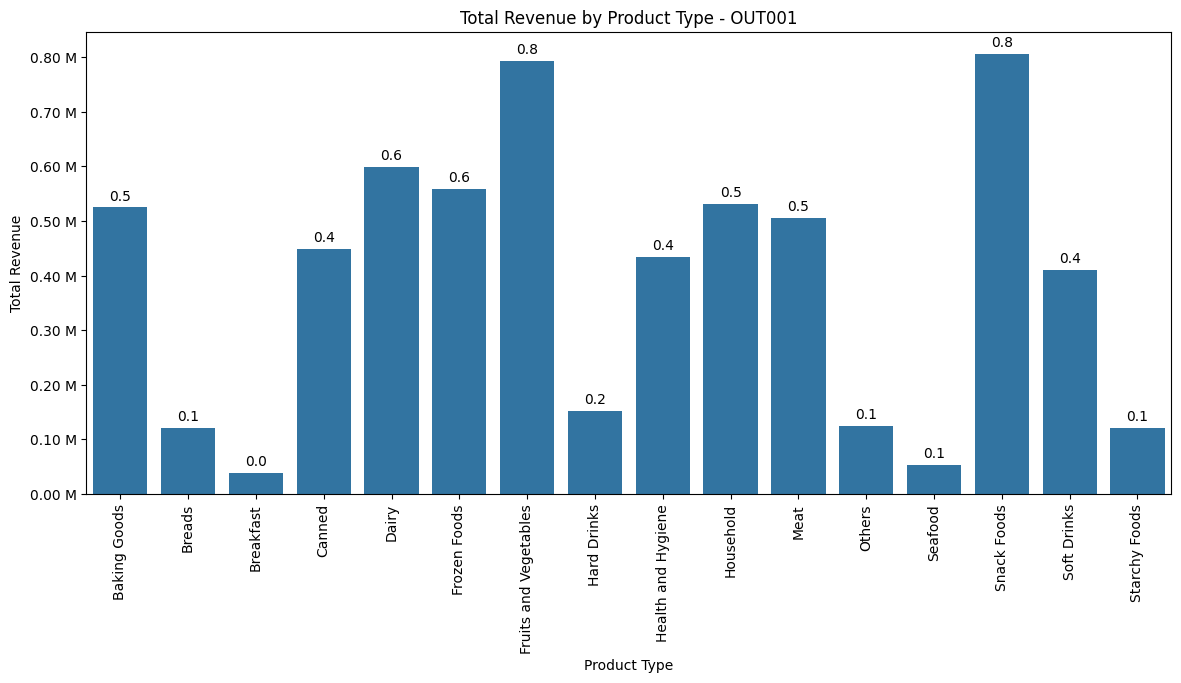

In [42]:
store_deep_dive("OUT001")

### 5.6.2 OUT002 - Food Mart, Small, Tier 3 (est. 1998)

=== Statistical summary for OUT002 ===
Total revenue: 2,030,909.72
Number of products sold: 1152
Store_Type: Food Mart
Store_Size: Small
City Tier: Tier 3
Established: 1998
Product MRP range: 31.00 to 224.93
Per-product revenue range: 33.00 to 2299.63



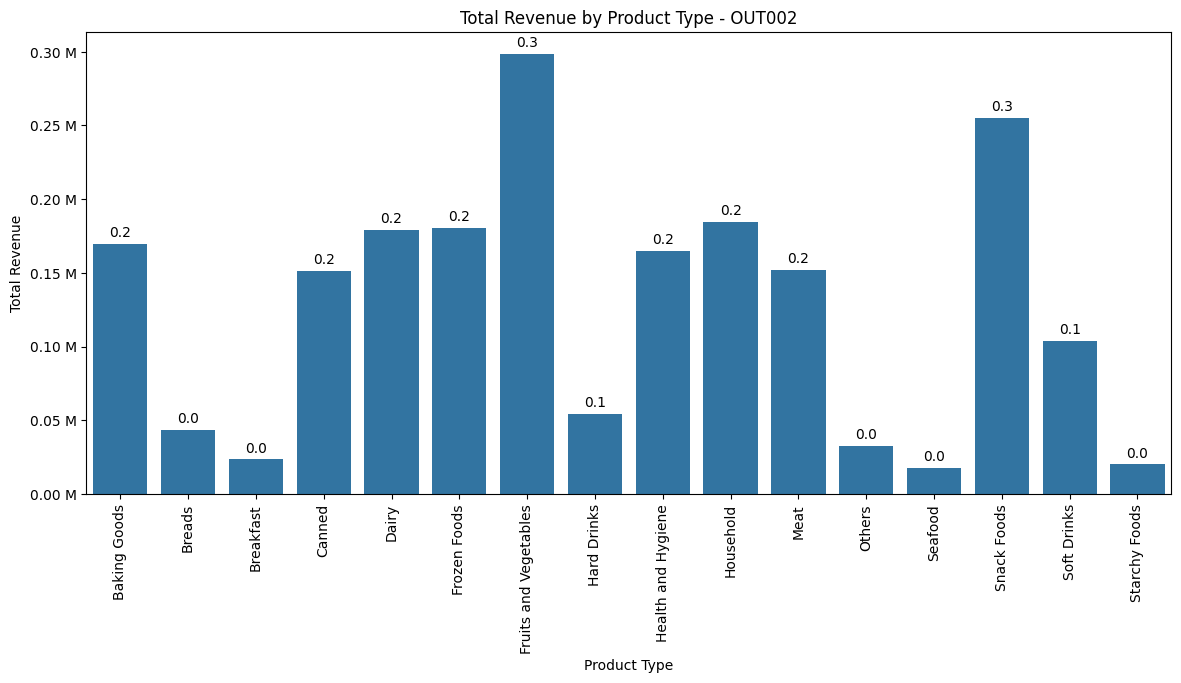

In [43]:
store_deep_dive("OUT002")

### 5.6.3 OUT003 - Departmental Store, Medium, Tier 1 (est. 1999)

=== Statistical summary for OUT003 ===
Total revenue: 6,673,457.57
Number of products sold: 1349
Store_Type: Departmental Store
Store_Size: Medium
City Tier: Tier 1
Established: 1999
Product MRP range: 85.88 to 266.00
Per-product revenue range: 3069.24 to 8000.00



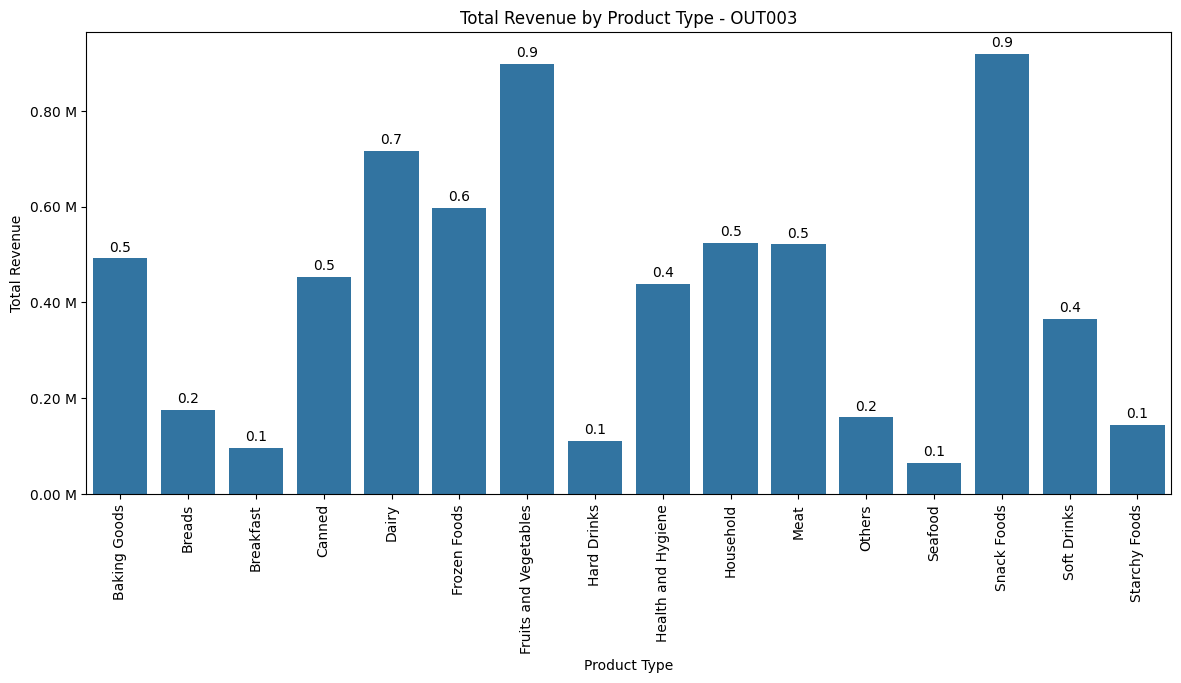

In [44]:
store_deep_dive("OUT003")

### 5.6.4 OUT004 - Supermarket Type2, Medium, Tier 2 (est. 2009)

=== Statistical summary for OUT004 ===
Total revenue: 15,427,583.43
Number of products sold: 4676
Store_Type: Supermarket Type2
Store_Size: Medium
City Tier: Tier 2
Established: 2009
Product MRP range: 83.04 to 197.66
Per-product revenue range: 1561.06 to 5462.86



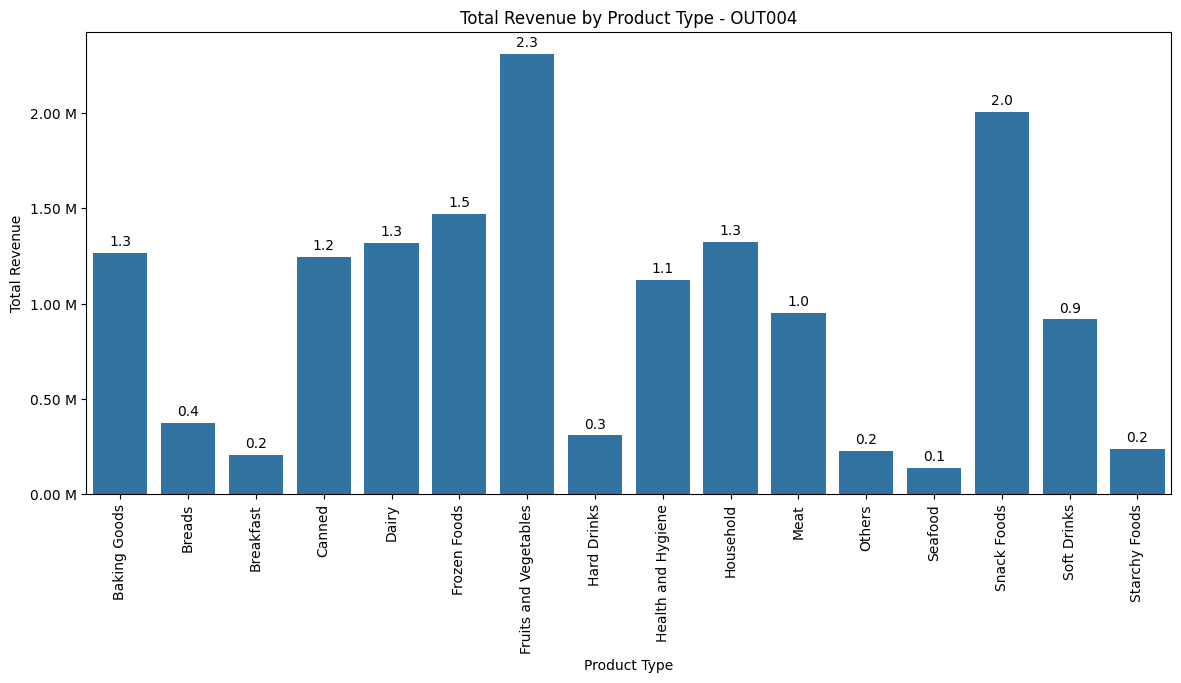

In [45]:
store_deep_dive("OUT004")

**Observations - Per-Store Deep Dive:**

Each of the four stores has a clearly distinct profile. Reading across the printed summaries and the bar plots:

**OUT001 - Supermarket Type1, High-size, Tier 2, established 1987**
- Total revenue: 6.22 million across 1,586 products.
- Per-product revenue range: 2,300 to 5,000.
- Top categories: Fruits and Vegetables (0.8M) and Snack Foods (0.8M), each contributing roughly 13% of the store's revenue.
- Solid mid-tier performer with a balanced category mix and moderate per-product revenue. The oldest store in the chain (39 years old at time of analysis).

**OUT002 - Food Mart, Small, Tier 3, established 1998**
- Total revenue: 2.03 million across 1,152 products. Lowest performer in the chain.
- Per-product revenue range: 33 to 2,300 - a strikingly low ceiling. No product at OUT002 generates more than about 2,300 in revenue, while every other store has products earning over 4,000.
- Top categories: Fruits and Vegetables and Snack Foods both at 0.3M.
- The MRP range (31 to 225) shows OUT002 stocks the cheapest products. Combined with its location in a Tier 3 city, this profile suggests a budget convenience-store role within the chain.

**OUT003 - Departmental Store, Medium, Tier 1, established 1999**
- Total revenue: 6.67 million across 1,349 products. Notable: more revenue than OUT001 from fewer products.
- Per-product revenue range: 3,070 to 8,000 - the highest minimum and the highest maximum in the entire chain.
- Top categories: Snack Foods (0.9M) and Fruits and Vegetables (0.9M).
- This store's MRP range starts at 86 (no cheap products) and reaches 266 (the highest in the dataset). Combined with the high per-product revenue floor, this is unambiguously a premium-positioned store. The Tier 1 city location reinforces this.

**OUT004 - Supermarket Type2, Medium, Tier 2, established 2009**
- Total revenue: 15.43 million across 4,676 products. Far and away the largest in the chain - more than the other three stores combined.
- Per-product revenue range: 1,561 to 5,463 - moderate per-product revenue compared to OUT001 and OUT003.
- Top categories: Fruits and Vegetables (2.3M) and Snack Foods (2.0M), each contributing around 14% of the store's revenue.
- The volume strategy is unambiguous: OUT004 stocks roughly three times as many products as the other stores and generates revenue through breadth rather than per-product margin. It is the newest store in the chain (17 years old).

**Cross-store synthesis:**

- Three of the four stores share Fruits and Vegetables and Snack Foods as their top two revenue categories. Only the relative ranking differs. These two categories are the chain-wide revenue

## 5.7 Multivariate Patterns

A few additional cross-feature plots that help us understand product positioning and store-level pricing strategies. These are useful for the business recommendations even if they do not directly drive modelling decisions.

### 5.7.1 Product_Type vs Product_Weight

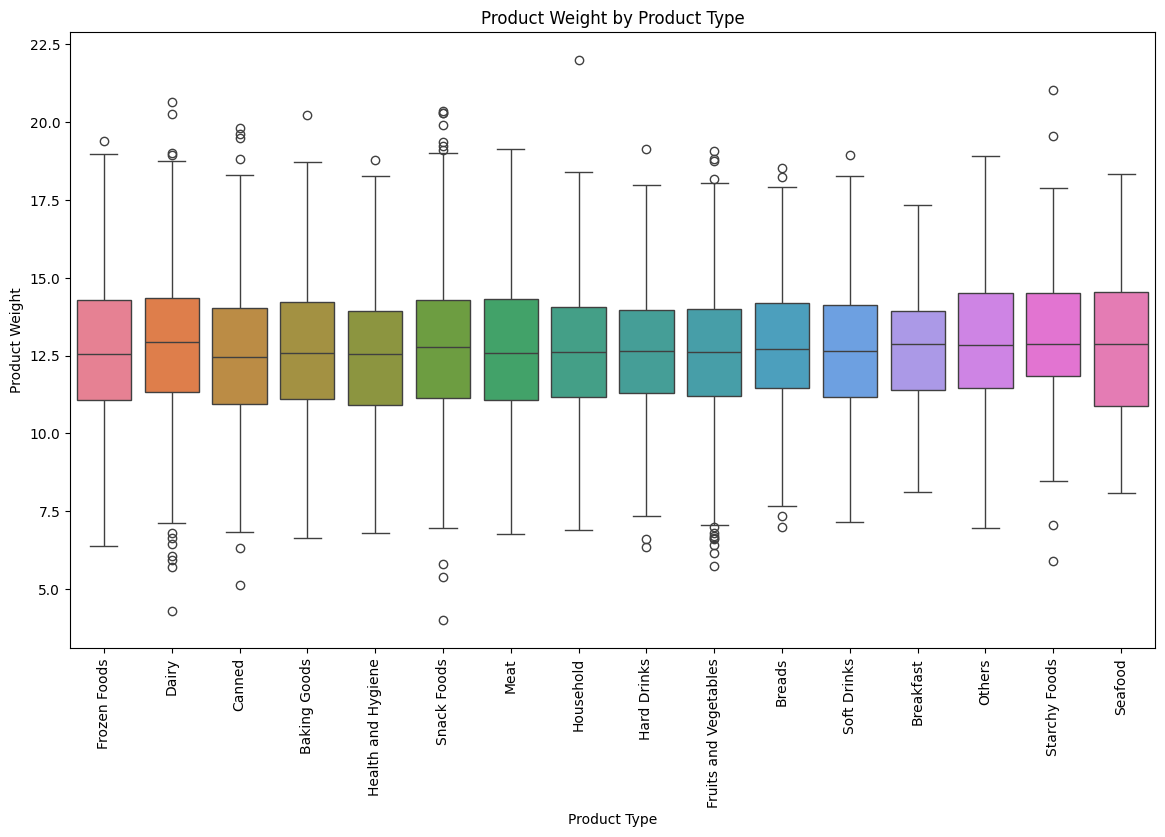

In [46]:
# Boxplot of weight by product type.
# We expect heavier products in some categories (rice, oils) and lighter in others
# (snacks, drinks). Confirms whether weight is a useful proxy for product category.
plt.figure(figsize=(14, 8))
sns.boxplot(data=data, x="Product_Type", y="Product_Weight", hue="Product_Type")
plt.xticks(rotation=90)
plt.title("Product Weight by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Product Weight")
plt.show()

### 5.7.2 Product_Sugar_Content vs Product_Weight

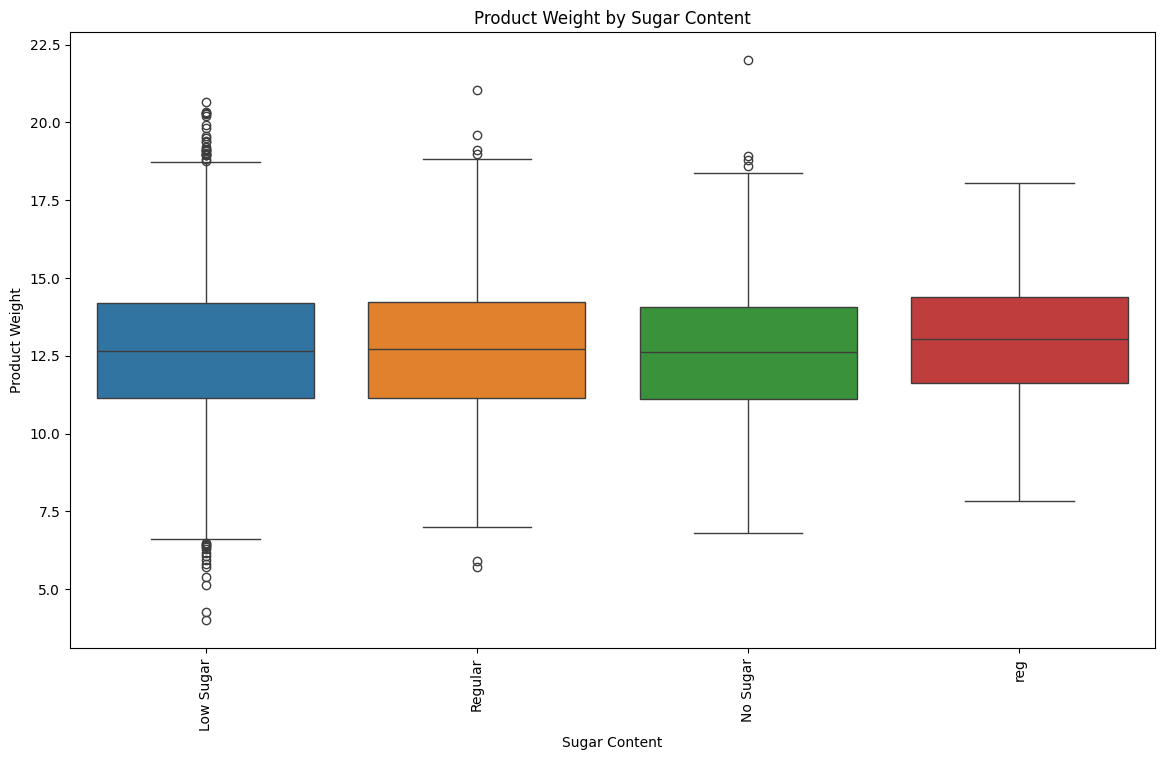

In [47]:
# Boxplot of weight by sugar content.
# Mostly a sanity check - we do not expect a strong relationship.
plt.figure(figsize=(14, 8))
sns.boxplot(data=data, x="Product_Sugar_Content", y="Product_Weight", hue="Product_Sugar_Content")
plt.xticks(rotation=90)
plt.title("Product Weight by Sugar Content")
plt.xlabel("Sugar Content")
plt.ylabel("Product Weight")
plt.show()

### 5.7.3 Sugar Content distribution across Product Types

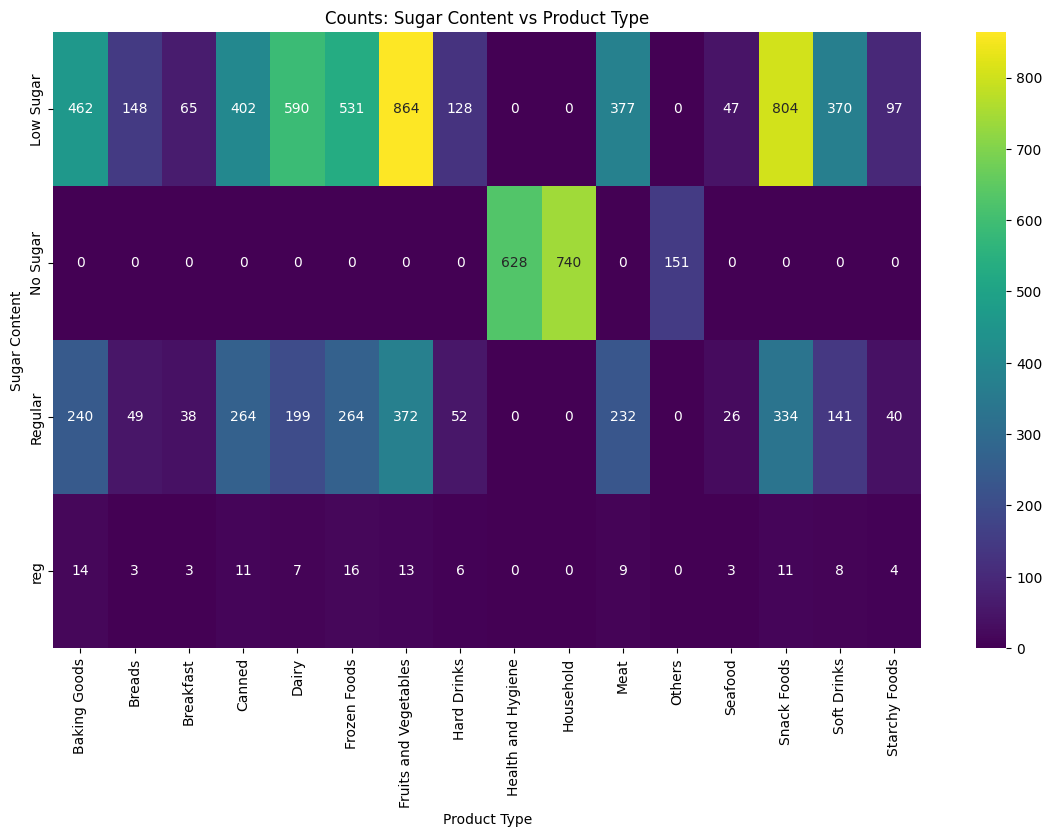

In [48]:
# Heatmap of crosstab between sugar content and product type.
# Annotated cells show the count of products in each combination.
# Useful for spotting which product types contribute to the sugar content categories.
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Sugar Content")
plt.xlabel("Product Type")
plt.title("Counts: Sugar Content vs Product Type")
plt.show()

### 5.7.4 Product Type distribution across Stores

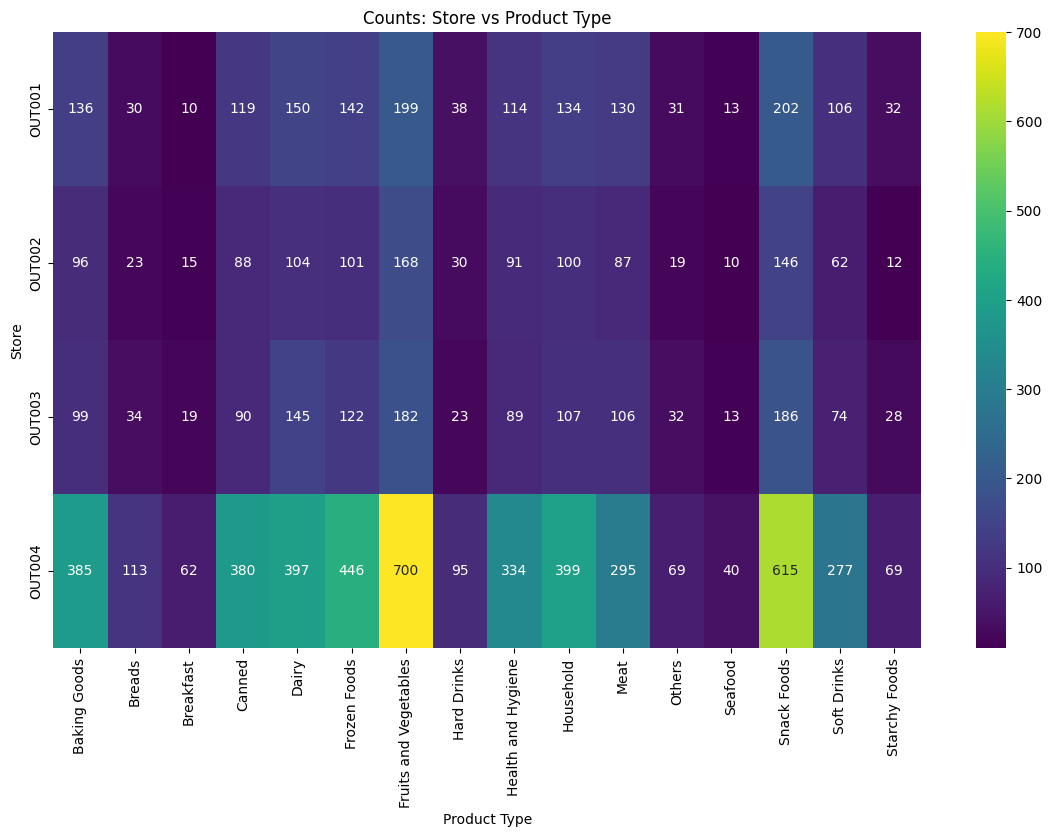

In [49]:
# Heatmap of crosstab between Store_Id and Product_Type.
# Shows how many products of each type are stocked at each store.
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Store_Id"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Store")
plt.xlabel("Product Type")
plt.title("Counts: Store vs Product Type")
plt.show()

### 5.7.5 Product MRP by Product Type

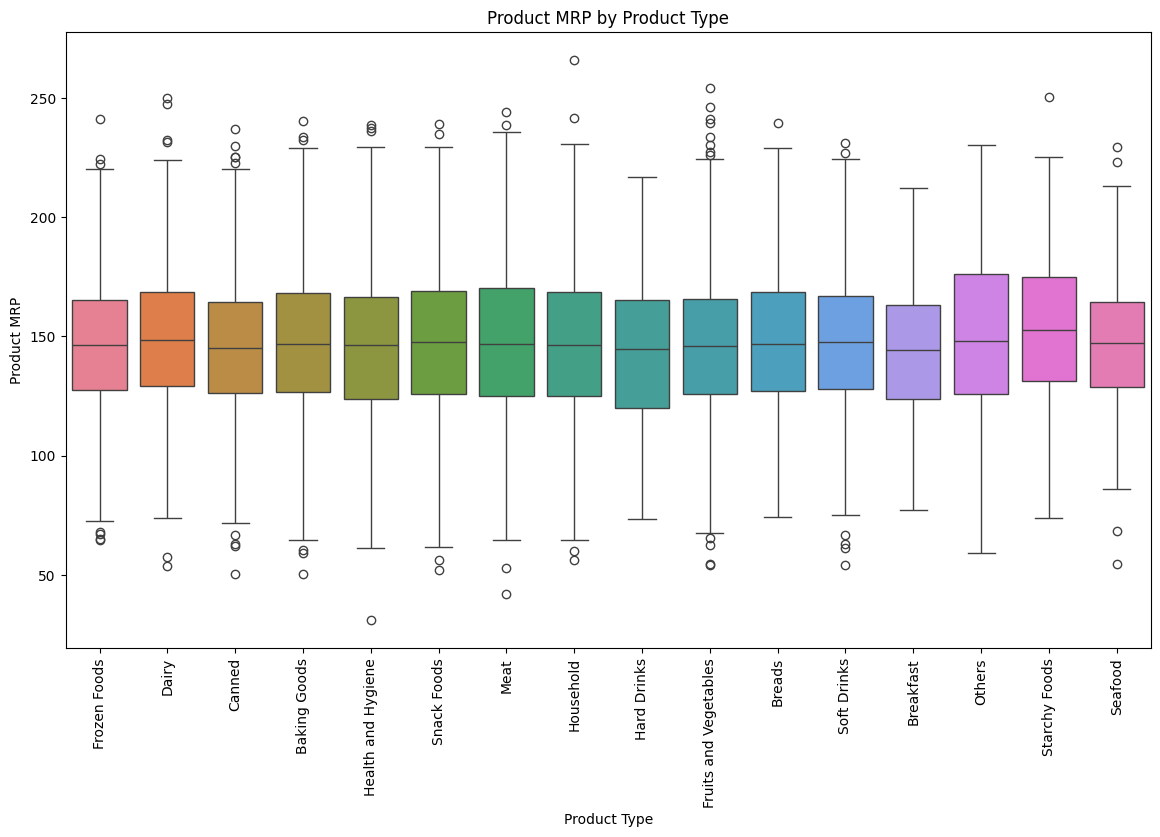

In [50]:
# Boxplot of MRP by product type.
# Shows the price range each product category occupies.
plt.figure(figsize=(14, 8))
sns.boxplot(data=data, x="Product_Type", y="Product_MRP", hue="Product_Type")
plt.xticks(rotation=90)
plt.title("Product MRP by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Product MRP")
plt.show()

### 5.7.6 Product MRP by Store

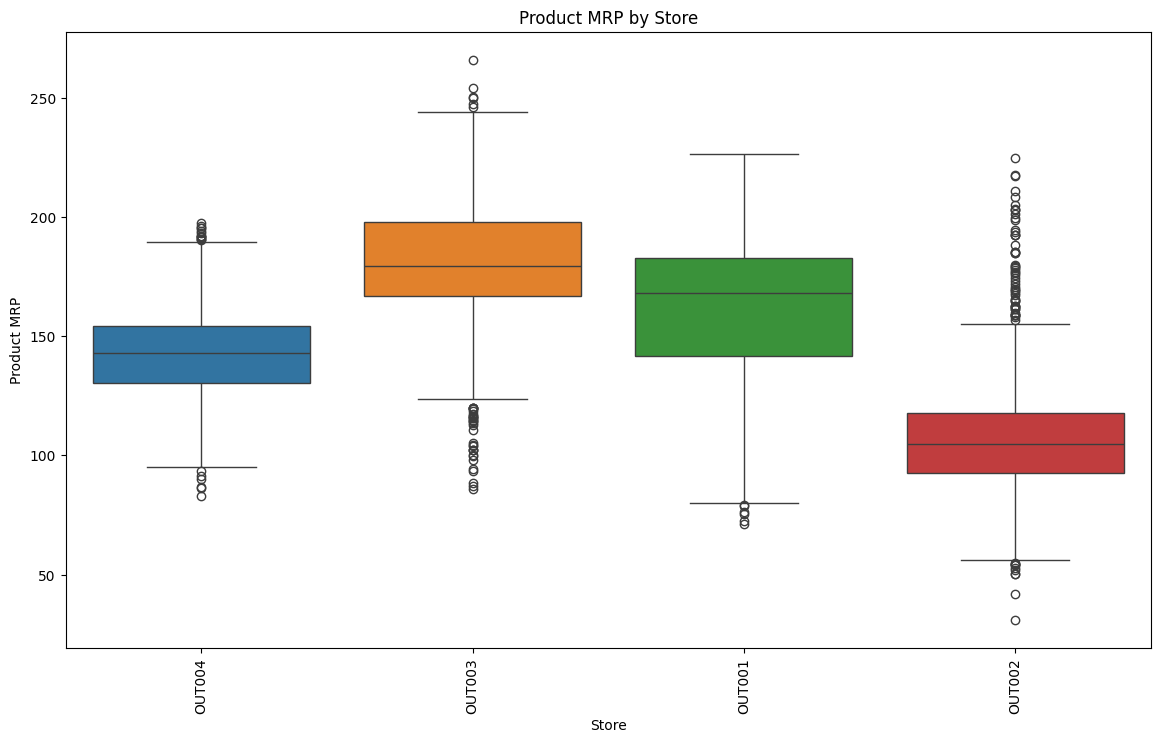

In [51]:
# Boxplot of MRP by store.
# Shows whether different stores carry different price ranges.
# Reinforces the premium-vs-budget store positioning we saw in section 5.6.
plt.figure(figsize=(14, 8))
sns.boxplot(data=data, x="Store_Id", y="Product_MRP", hue="Store_Id")
plt.xticks(rotation=90)
plt.title("Product MRP by Store")
plt.xlabel("Store")
plt.ylabel("Product MRP")
plt.show()

**Observations - Multivariate Patterns:**

**Weight by Product Type (5.7.1):** All 16 product types share nearly identical weight distributions, with medians around 12 to 13 and IQRs broadly overlapping. There is no meaningful relationship between product category and product weight. This is informative because it tells us Product_Weight is carrying information that is genuinely independent of Product_Type - weight is not a proxy for category.

**Weight by Sugar Content (5.7.2):** No meaningful relationship. All four sugar categories show similar weight distributions. Confirms what we expected.

**Sugar Content vs Product Type heatmap (5.7.3):** This is the most informative plot in this section. The "No Sugar" category is used exclusively for non-food products: Health and Hygiene (628), Household (740), and Others (151). Every other Product_Type uses Low Sugar, Regular, or "reg" but never No Sugar. This tells us "No Sugar" is functioning as a placeholder for non-consumable products where sugar content is not a meaningful attribute. This insight directly supports the Product_Id prefix engineering we are about to do (NC = Non-Consumable maps cleanly to No Sugar).

**Store vs Product Type heatmap (5.7.4):** Confirms what we already knew - OUT004 stocks the most products in every category. The relative product mix is fairly consistent across stores (Fruits and Vegetables and Snack Foods top everywhere), with OUT002 being the most modest in absolute counts.

**MRP by Product Type (5.7.5):** All 16 product types share similar MRP distributions with medians around 145 to 150. Product_MRP carries no meaningful category-specific signal - any product can be priced anywhere in the MRP range.

**MRP by Store (5.7.6):** This plot crisply confirms the store-positioning hypothesis from section 5.6. The MRP medians are clearly separated:
- OUT003 (Departmental Store, Tier 1): median around 180, premium price range
- OUT001 (Supermarket Type1, Tier 2): median around 165
- OUT004 (Supermarket Type2, Tier 2): median around 145, mid-market
- OUT002 (Food Mart, Tier 3): median around 105, budget

This is direct evidence that each store operates a distinct pricing strategy, not just a different product mix. The pricing tier aligns with the city tier (Tier 1 commands premium pricing, Tier 3 stocks budget items). This gives us material for a pricing-strategy recommendation in section 12.

## 5.8 EDA Insights Summary

This section consolidates the most important findings from the entire EDA. These insights drive our preprocessing decisions in section 6, our feature engineering choices, and the business recommendations in section 12.

**Top EDA insights:**

**1. Product_MRP and Product_Weight are the strongest predictors of revenue.**
Pearson correlations of 0.79 and 0.74 respectively. Together they will likely explain a large portion of the model's variance.

**2. Product_Allocated_Area has zero correlation with revenue.**
The amount of display area allocated to a product does not predict its sales revenue. This challenges a core assumption in retail merchandising and is a strong signal for the recommendations section.

**3. The chain operates four distinct store profiles, not four similar stores.**
- OUT003 (Tier 1 Departmental Store, est. 1999): premium positioning, highest per-product revenue (median around 4,900), MRP median around 180.
- OUT004 (Tier 2 Supermarket Type2, est. 2009): high-volume strategy, 4,676 products generating 15.4M revenue.
- OUT001 (Tier 2 Supermarket Type1, est. 1987): balanced mid-tier supermarket.
- OUT002 (Tier 3 Food Mart, est. 1998): budget positioning, lowest per-product revenue (median around 1,900), MRP median around 105.

**4. Pricing strategy is correlated with city tier.**
Tier 1 stocks premium-priced products, Tier 3 stocks budget items. This is consistent across the chain and aligns with consumer purchasing power.

**5. Two product categories drive ~30% of chain-wide revenue.**
Fruits and Vegetables and Snack Foods together generate roughly 8.3M of the chain's 30.4M total revenue. They are top-2 revenue categories at every store.

**6. The "No Sugar" sugar-content category is exclusively assigned to non-consumable products.**
Health and Hygiene, Household, and Others account for all No Sugar entries. This means Sugar_Content is essentially a derived feature of product type, not a true attribute. Useful insight for feature engineering.

**7. Data quality issue confirmed: Product_Sugar_Content has a stray "reg" category (1.2% of rows) that is a misspelling of Regular.**
Will be merged in preprocessing.

**8. Heavy categorical redundancy at the store level.**
Store_Id, Store_Type, Store_Size, Store_Location_City_Type, and Store_Establishment_Year all carry overlapping information about the same four stores. We will drop Store_Id and Store_Establishment_Year in preprocessing and rely on the more general categorical features plus the engineered Store_Age_Years.

**9. Product_Id contains a hidden categorical signal (FD, NC, DR prefixes).**
We will extract the two-character prefix as a feature in preprocessing. This will likely correspond to Food, Non-Consumable, and Drink categorisations.

**10. Data is well-behaved overall.**
No missing values, no duplicates, no severe skew, no zero pile-ups. Outliers exist but appear to reflect genuine variation. No aggressive cleaning or transformation is required.

These ten findings shape every decision in the rest of the notebook.

# 6. Data Preprocessing

This section transforms the raw data into a clean, model-ready feature set. Each transformation is driven by a finding from EDA. Before any modelling, we work on a fresh copy of the data so we always have the cleaned EDA-stage data to compare against.

## 6.1 Standardising Sugar-Content Labels

EDA observation 7 flagged a data quality issue: Product_Sugar_Content has 4 unique values (Low Sugar, Regular, No Sugar, reg) but the data dictionary specifies only 3. The "reg" category contains 108 rows and is a typo or shorthand for Regular. We replace "reg" with "Regular" so the model sees the intended three-category structure.

In [52]:
# Replace the stray "reg" category with "Regular".
# We use replace() rather than a manual loop because it is vectorised
# and creates a new column rather than modifying values one by one.
data["Product_Sugar_Content"] = data["Product_Sugar_Content"].replace(
    {"reg": "Regular"}
)

# Verify the fix worked: we should now see exactly 3 categories.
print("Sugar content categories after cleaning:")
print(data["Product_Sugar_Content"].value_counts())

Sugar content categories after cleaning:
Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64


In [53]:
# Sanity check: confirm there are exactly 3 unique values now.
unique_count = data["Product_Sugar_Content"].nunique()
print(f"Number of unique sugar content categories: {unique_count}")
assert unique_count == 3, "Expected exactly 3 sugar content categories after cleanup."
print("Cleanup successful.")

Number of unique sugar content categories: 3
Cleanup successful.


**Observations:**

- The "reg" category has been merged into "Regular" successfully.
- Final category counts: Low Sugar (4885), Regular (2359), No Sugar (1519). The Regular total of 2359 equals the original Regular count (2251) plus the merged "reg" rows (108), confirming the merge worked correctly.
- The data now matches the data dictionary specification of three sugar content categories.

## 6.2 Feature Engineering - Product ID Prefix

EDA observation 9 flagged that Product_Id starts with two letters (FD, NC, DR) that appear to encode a coarse product category. We extract these prefixes into a new column called Product_Id_char and verify what each prefix corresponds to.

This is a useful feature to engineer because:
- The original Product_Id has 8763 unique values (one per row), so it cannot be used as a model feature directly.
- The prefix is a low-cardinality categorical (3 values) that the model can use.
- It captures the broad consumable / non-consumable / drink distinction without the noise of 16 product types.

In [54]:
# Extract the first two characters of every Product_Id into a new column.
# str[:2] takes characters at index 0 and 1 (the two letters before the digits).
data["Product_Id_char"] = data["Product_Id"].str[:2]

# Quick check: which prefixes exist and how many rows each contains?
print("Distribution of Product_Id prefixes:")
print(data["Product_Id_char"].value_counts())

Distribution of Product_Id prefixes:
Product_Id_char
FD    6539
NC    1519
DR     705
Name: count, dtype: int64


In [55]:
# For each prefix, list the Product_Types it appears in.
# This validates whether our hypothesis (FD = Food, NC = Non-Consumable, DR = Drinks) is correct.
for prefix in data["Product_Id_char"].unique():
    types_for_prefix = data.loc[data["Product_Id_char"] == prefix, "Product_Type"].unique()
    print(f"\nProducts with prefix '{prefix}' ({(data['Product_Id_char'] == prefix).sum()} rows):")
    print(f"  Product types: {sorted(types_for_prefix)}")


Products with prefix 'FD' (6539 rows):
  Product types: ['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy', 'Frozen Foods', 'Fruits and Vegetables', 'Meat', 'Seafood', 'Snack Foods', 'Starchy Foods']

Products with prefix 'NC' (1519 rows):
  Product types: ['Health and Hygiene', 'Household', 'Others']

Products with prefix 'DR' (705 rows):
  Product types: ['Hard Drinks', 'Soft Drinks']


**Observations:**

The data dictionary does not document what the two-letter prefixes mean, so we examined which Product_Types each prefix appears with to understand its function. Each prefix maps to a distinct, non-overlapping set of product types:

- **FD (6539 rows, 74.6%)**: Baking Goods, Breads, Breakfast, Canned, Dairy, Frozen Foods, Fruits and Vegetables, Meat, Seafood, Snack Foods, Starchy Foods. Eleven product types - all of these are food items.
- **NC (1519 rows, 17.3%)**: Health and Hygiene, Household, Others. Three product types - none of which are food or drink.
- **DR (705 rows, 8.0%)**: Hard Drinks, Soft Drinks. Two product types - both drinks.

Based on the groupings, FD, NC, and DR appear to function as broad product-class identifiers, though the data dictionary does not explicitly confirm this naming convention.

Two important confirmations from this validation:

1. The earlier finding from EDA section 5.7.3 now connects: "No Sugar" was exclusively used for Health and Hygiene, Household, and Others - exactly the three NC categories. The sugar content field uses "No Sugar" as a placeholder for products in the NC group rather than as a true attribute of those products.

2. Product_Id_char gives the model a clean three-level categorical that captures broad product groupings at much lower cardinality than Product_Type's sixteen levels. After one-hot encoding, this is three columns instead of sixteen, which simplifies the feature space without losing the broad-category information.

## 6.3 Feature Engineering - Store Age

Store_Establishment_Year is a meaningful field but its raw value (e.g., 1987 or 2009) is not the most useful representation for a model. The model would have to learn that "2009" means a younger store - it is easier to give it the age directly.

We compute Store_Age_Years as a fixed reference year minus Store_Establishment_Year. The reference year choice is somewhat arbitrary: any constant works because the model learns relative differences across stores. We use 2025 to match the project specification, though using 2026 (the year of analysis) would simply shift every age by 1 - the model would behave identically.

In [56]:
# Reference year for computing store age. Defined as a constant for clarity.
# Choosing a fixed year rather than the current year keeps the model's age
# values stable across runs (otherwise the same store would appear "older"
# each year the notebook is rerun, which would silently change predictions).
REFERENCE_YEAR = 2025

# Compute store age in years.
# Note: this is a per-row computation but Store_Establishment_Year is
# constant within a store, so Store_Age_Years effectively has only 4 distinct values.
data["Store_Age_Years"] = REFERENCE_YEAR - data["Store_Establishment_Year"]

# Verify: print the unique combinations of Store_Id, Establishment_Year, and Age.
print("Store age summary:")
print(
    data[["Store_Id", "Store_Establishment_Year", "Store_Age_Years"]]
    .drop_duplicates()
    .sort_values("Store_Id")
    .reset_index(drop=True)
)

Store age summary:
  Store_Id  Store_Establishment_Year  Store_Age_Years
0   OUT001                      1987               38
1   OUT002                      1998               27
2   OUT003                      1999               26
3   OUT004                      2009               16


**Observations:**

- The Store_Age_Years feature has been computed correctly using a reference year of 2025.
- Store ages: OUT001 = 38, OUT002 = 27, OUT003 = 26, OUT004 = 16.
- Because Store_Establishment_Year is constant within a store, Store_Age_Years effectively has only four distinct values across the entire dataset. This is a low-information feature on its own but adds value as part of the broader store-level signal.
- We will drop the original Store_Establishment_Year later when we drop redundant columns - keeping both would give the model two views of the same information.

## 6.4 Feature Engineering - Perishables vs Non-Perishables

EDA observation 5 noted that Product_Type has sixteen categories, several of which are very rare (Seafood at 0.9%, Breakfast at 1.2%, Starchy Foods at 1.6%, Others at 1.7%, Hard Drinks at 2.1%, Breads at 2.3%). Rare categories are problematic after one-hot encoding because each becomes a sparse column with very few positive examples for the tree to learn from.

We create a coarser feature called Product_Type_Category that groups the sixteen types into two groups: Perishables and Non Perishables. The model can use both Product_Type (granular, sixteen levels) and Product_Type_Category (coarse, two levels), letting it pick whichever is more useful at any given split.

The grouping rule we apply: Dairy, Meat, Fruits and Vegetables, Breakfast, Breads, and Seafood are perishables (food items with short shelf life). Everything else is treated as non-perishable.

In [57]:
# Define the list of product types we treat as perishable.
# Perishables share short shelf life, refrigeration requirements,
# and faster inventory turnover - characteristics that may correlate
# with revenue patterns.
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

# Apply a simple lambda to bucket each row into Perishables or Non Perishables.
# We use apply rather than np.where for readability with a longer list.
data["Product_Type_Category"] = data["Product_Type"].apply(
    lambda x: "Perishables" if x in perishables else "Non Perishables"
)

# Verify the new column.
print("Product_Type_Category distribution:")
print(data["Product_Type_Category"].value_counts())
print(f"\nProportion of perishables: "
      f"{(data['Product_Type_Category'] == 'Perishables').mean():.1%}")

Product_Type_Category distribution:
Product_Type_Category
Non Perishables    5718
Perishables        3045
Name: count, dtype: int64

Proportion of perishables: 34.7%


**Observations:**

- Product_Type_Category has been created with two values: Non Perishables (5718 rows, 65.3%) and Perishables (3045 rows, 34.7%).
- The split is reasonably balanced. Both categories have several thousand rows, which gives the model adequate examples for each.
- The granular Product_Type column is retained alongside this new feature. The model can use whichever level of granularity is most useful at any given split - the coarse two-level grouping for broad effects, the sixteen-level original for fine-grained product distinctions.

## 6.5 Outlier Detection and Treatment Decision

We saw outliers in the boxplots throughout EDA - dots beyond the whiskers on Product_Weight, Product_Allocated_Area, Product_MRP, and Product_Store_Sales_Total. We now check them visually one more time on the post-cleaning data and make an explicit decision about treatment.

Treatment options for outliers in regression problems include:
- Removing rows with extreme values (caps the data range).
- Winsorising or clipping (replacing extreme values with percentile thresholds).
- Log-transforming the affected feature (compresses the right tail).
- Leaving them in (relying on the model to handle them).

The right choice depends on whether the outliers are data errors or genuine variation, and on how sensitive the chosen model is to extreme values.

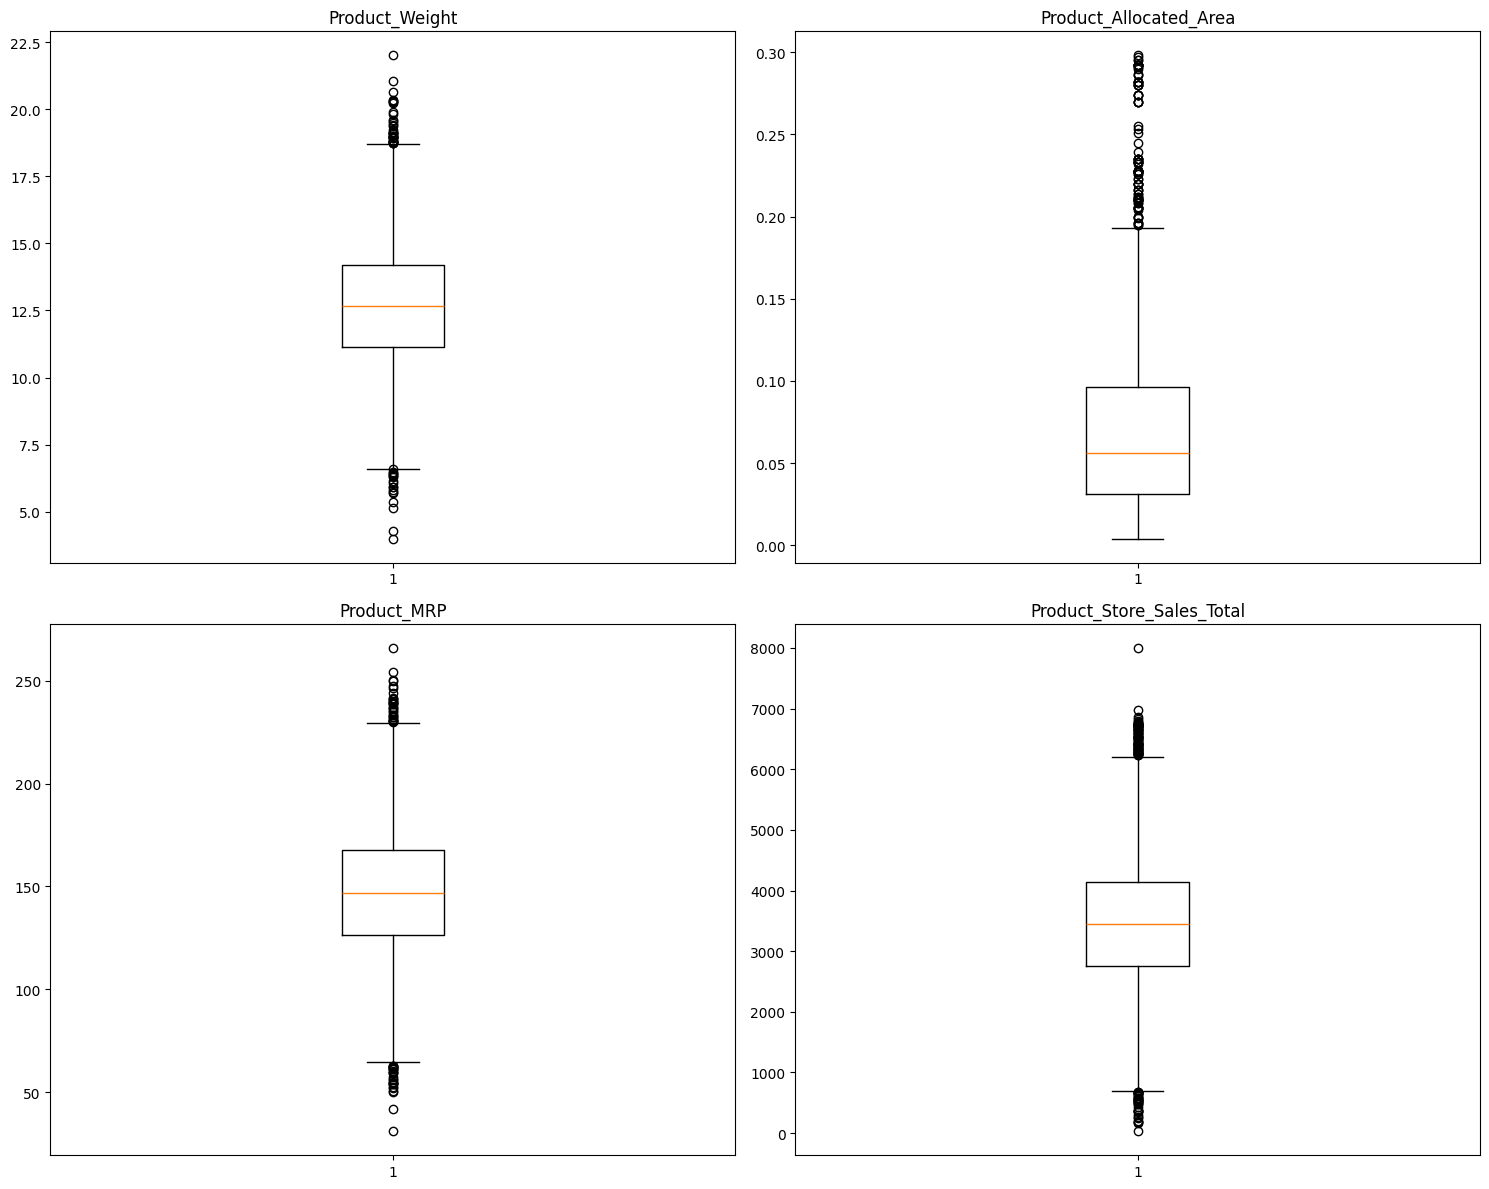

In [58]:
# Re-plot boxplots for the numerical columns after our preprocessing.
# We exclude Store_Establishment_Year and Store_Age_Years because they
# only have four distinct values - boxplots are not meaningful for those.
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")

plt.figure(figsize=(15, 12))
for i, variable in enumerate(numeric_columns):
    plt.subplot(2, 2, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)
plt.show()

**Observations and Treatment Decision:**

All four numerical features show outliers (points beyond the 1.5 x IQR whiskers in the boxplots above):

- **Product_Weight**: outliers on both ends, mostly above 18.5 and a few below 7.
- **Product_Allocated_Area**: a long tail of outliers above 0.20, no outliers on the low end.
- **Product_MRP**: outliers on both ends, mostly above 230 and a few below 65.
- **Product_Store_Sales_Total** (target): outliers on both ends, with extreme high points reaching toward 8000 and low points near zero.

**Decision: We do not treat the outliers. They are retained as-is.**

**Rationale:**

1. **The outliers reflect genuine variation, not data errors.** During the per-store deep dive (section 5.6), we saw that OUT002 has a per-product revenue range from 33 to 2300 - very low values exist because OUT002 is a small Food Mart in a Tier 3 city stocking budget items. These low revenue points appear as outliers in the chain-wide boxplot but they are valid observations of how that store actually operates. Removing them would erase information about how budget stores behave.

2. **Tree-based models are inherently robust to outliers.** Random Forest and XGBoost split the data on threshold values rather than fitting a smooth function to the entire range. An extreme observation contributes to one branch of one tree but does not pull the global fit the way it would in linear regression. Outlier treatment is mainly a concern for distance-based and gradient-based linear methods, neither of which we are using.

3. **The outlier points are sparse and not concentrated in a single region.** They are scattered along the tail rather than forming a cluster that might suggest a separate data-generating process. Capping or winsorising these spread-out points would primarily reduce the model's exposure to legitimate edge cases without addressing any real problem.

4. **No transformation is needed for the target.** Product_Store_Sales_Total has a roughly symmetric distribution (we confirmed in section 5.1.4), so log-transforming it would not improve modelling and would make RMSE harder to interpret in real revenue units.

5. **The deployed model needs to handle realistic edge cases.** In production, the API will receive products with extreme weights, unusual MRPs, and atypical allocated areas. A model trained without those edge cases would make poor predictions on them. Keeping the outliers in training data improves the model's generalisation to rare but valid inputs.

In summary, the outliers are real, the chosen models handle them natively, and removing them would degrade rather than improve generalisation. We move forward with the data as-is.

## 6.6 Data Preparation - Drop Redundant Columns and Train/Test Split

We now drop the columns that are either redundant (information already captured by other features) or unsuitable as model inputs (high-cardinality identifiers). Then we separate features from the target and split the data into training and test sets.

**Columns to drop and why:**

- **Product_Id**: 8763 unique values, one per row. Cannot be used as a feature - its information has already been extracted into Product_Id_char.
- **Product_Type**: We retain it as a feature in some implementations, but we will drop it here in favour of the coarser Product_Type_Category. The 16-level Product_Type would create a very wide one-hot encoding with several sparse columns, and we have already noted Product_Type and Product_MRP medians are nearly identical across categories (no distinct price tiers per type). The model will learn product effects via Product_Id_char (3 levels) and Product_Type_Category (2 levels) combined with the strong numerical predictors.
- **Store_Id**: 4 unique values that are perfectly correlated with Store_Type, Store_Size, and Store_Location_City_Type. Keeping it would create redundant signal.
- **Store_Establishment_Year**: Already replaced by Store_Age_Years, which is more directly meaningful.

**Columns we retain:** Product_Weight, Product_Sugar_Content, Product_Allocated_Area, Product_MRP, Store_Size, Store_Location_City_Type, Store_Type, Product_Id_char, Store_Age_Years, Product_Type_Category, and the target Product_Store_Sales_Total.

In [59]:
# Show the current columns before dropping, for transparency.
print("Columns before dropping:")
print(data.columns.tolist())
print(f"Shape: {data.shape}\n")

# Drop the four redundant or unusable columns.
data = data.drop(
    columns=["Product_Id", "Product_Type", "Store_Id", "Store_Establishment_Year"]
)

print("Columns after dropping:")
print(data.columns.tolist())
print(f"Shape: {data.shape}")

Columns before dropping:
['Product_Id', 'Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id', 'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Store_Sales_Total', 'Product_Id_char', 'Store_Age_Years', 'Product_Type_Category']
Shape: (8763, 15)

Columns after dropping:
['Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_MRP', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Store_Sales_Total', 'Product_Id_char', 'Store_Age_Years', 'Product_Type_Category']
Shape: (8763, 11)


**Observations:**

- The dataset now has 8763 rows and 11 columns (10 features plus the target).
- Dropped columns: Product_Id, Product_Type, Store_Id, Store_Establishment_Year.
- Retained columns: Product_Weight, Product_Sugar_Content, Product_Allocated_Area, Product_MRP, Store_Size, Store_Location_City_Type, Store_Type, Product_Id_char, Store_Age_Years, Product_Type_Category, Product_Store_Sales_Total.
- The retained feature set matches the input contract that the deployed API will use, ensuring training and inference operate on the same schema.

### 6.6.1 Separating Features from Target and Splitting Train/Test

We now separate the feature matrix X from the target vector y, then split into training and test sets in a 70:30 ratio. The test set is held out from all training and tuning - we touch it only once at the very end to estimate generalisation performance.

We use random_state=1 for reproducibility - any reader running this notebook will get the exact same split.

In [60]:
# Separate features (X) from the target (y).
# X holds the 10 predictor columns; y holds Product_Store_Sales_Total.
X = data.drop("Product_Store_Sales_Total", axis=1)
y = data["Product_Store_Sales_Total"]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features (X) shape: (8763, 10)
Target (y) shape: (8763,)

Feature columns: ['Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_MRP', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char', 'Store_Age_Years', 'Product_Type_Category']


In [61]:
# Split into training and test sets in 70:30 ratio.
# - test_size=0.3 means 30% of rows go to the test set.
# - random_state=1 ensures reproducibility.
# - shuffle=True (the default) randomises before splitting, important here
#   because the data may be ordered by store or product type.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, shuffle=True
)

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape:     X_test={X_test.shape},  y_test={y_test.shape}")
print(f"\nTraining set: {len(X_train)} rows ({len(X_train)/len(X):.1%})")
print(f"Test set:     {len(X_test)} rows ({len(X_test)/len(X):.1%})")

Training set shape: X_train=(6134, 10), y_train=(6134,)
Test set shape:     X_test=(2629, 10),  y_test=(2629,)

Training set: 6134 rows (70.0%)
Test set:     2629 rows (30.0%)


**Observations:**

- Features (X) shape: 8763 rows by 10 columns.
- Target (y) shape: 8763 rows.
- Training set: 6134 rows (70.0%).
- Test set: 2629 rows (30.0%).
- The split is reproducible thanks to random_state=1.
- The training set has plenty of data for tree-based models. The test set has 2629 rows, which is more than enough to produce stable estimates of generalisation performance.
- We will not touch the test set again until after final model selection and serialisation. All hyperparameter tuning is done using cross-validation on the training set only.

## 6.7 Preprocessing Pipeline (Categorical Encoding)

We need to convert categorical features (Product_Sugar_Content, Store_Size, Store_Location_City_Type, Store_Type, Product_Id_char, Product_Type_Category) into a numerical representation that the tree models can consume. We use one-hot encoding via sklearn's OneHotEncoder wrapped in a ColumnTransformer.

**Why this approach:**

1. **Pipeline-based encoding.** The encoder is part of a sklearn Pipeline, which means it gets fit on the training data and saved alongside the model. When the model is loaded for prediction at deployment, the same encoder is applied to incoming data automatically. We do not have to manually replicate the transformation in the API.

2. **handle_unknown="ignore".** If the deployed API receives a category it has not seen in training (e.g. a new Store_Type), the encoder will produce an all-zeros encoding for that row rather than crashing. This is a safety net for production.

3. **No StandardScaler.** We are using only tree-based models, which are scale-invariant. Adding a scaler would add complexity for no benefit.

4. **Numerical features pass through unchanged.** The ColumnTransformer's default behaviour is to drop columns it does not transform. Since we only transform the categorical columns and want to keep numerical ones as-is, we will explicitly handle this.

In [62]:
# Identify categorical columns from the dataset (object/string dtypes).
# We list them explicitly rather than auto-detecting at runtime so the
# pipeline behaviour is deterministic and easy to audit.
categorical_features = [
    "Product_Sugar_Content",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Product_Type_Category",
]

# Sanity check: confirm these match what the data actually has.
detected_cats = data.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical columns we declared: {categorical_features}")
print(f"Categorical columns in the data: {detected_cats}")
assert set(categorical_features) == set(detected_cats), \
    "Mismatch between declared and detected categorical columns."
print("\nCategorical column lists match.")

# Build the preprocessor.
# make_column_transformer:
#   - Applies OneHotEncoder to the listed categorical features.
#   - Lets all other columns (numerical) pass through unchanged via remainder='passthrough'.
# OneHotEncoder(handle_unknown='ignore'):
#   - Creates one binary column per category.
#   - Returns all zeros for any unseen category at inference time (safety net).
preprocessor = make_column_transformer(
    (Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    remainder="passthrough",
)

print("\nPreprocessing pipeline defined successfully.")
print(preprocessor)

Categorical columns we declared: ['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char', 'Product_Type_Category']
Categorical columns in the data: ['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char', 'Product_Type_Category']

Categorical column lists match.

Preprocessing pipeline defined successfully.
ColumnTransformer(remainder='passthrough',
                  transformers=[('pipeline',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Product_Sugar_Content', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type',
                                  'Product_Id_char',
                                  'Product_Type_Category'])])


**Observations:**

- The categorical columns declared in code match those detected in the data, confirming our feature engineering is consistent with the schema we have in memory.
- The ColumnTransformer applies OneHotEncoder to all 6 categorical features and passes the 4 numerical features through unchanged.
- handle_unknown="ignore" provides a safety net: at inference time, any unseen category will be encoded as all zeros rather than causing the API to crash.
- The pipeline is now ready to be combined with each model. When we wrap a model in make_pipeline(preprocessor, model), training data flows through the encoder first and then into the model. Saving the pipeline saves both the fitted encoder and the trained model, which guarantees the deployed API applies identical transformations to incoming requests.

# **Model Building**

## Define functions for Model Evaluation

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

# **Model Performance Improvement - Hyperparameter Tuning**

# **Model Performance Comparison, Final Model Selection, and Serialization**

# **Deployment - Backend**

## Flask Web Framework


## Dependencies File

## Dockerfile

## Setting up a Hugging Face Docker Space for the Backend

## Uploading Files to Hugging Face Space (Docker Space)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

## Dependencies File

## DockerFile

In [ ]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

## Uploading Files to Hugging Face Space (Streamlit Space)

# **Actionable Insights and Business Recommendations**

-

-